Na etapa de EDA, o grupo deve realizar uma análise exploratória abrangente para entender a estrutura, qualidade, distribuições, relações entre variáveis (numéricas e categóricas) e desafios, como missing values e vieses, preparando para encoding e modelagem nas fases subsequentes.
Descrição do Dataset: O dataset Adult consiste em 48.842 instâncias, cada uma representando um indivíduo com 14 features mistas e o target 'income'. Valores ausentes são representados por '?'. Use o conjunto completo para EDA, mas amostras estratificadas (por income) para visualizações eficientes se necessário.

Tarefas básicas de EDA:

# 1. Carregamento e Inspeção Inicial dos Dados

- Explicar cada feature do dataset.
- Verificar o número de instâncias e features.
- Identificar tipos de dados (numéricos e categóricos).
- Detectar valores ausentes (`?`) e inconsistências.
- Analisar a distribuição do target `income`.

In [30]:
import pandas as pd
import numpy as np

# Ler arquivo de documentação para entender o dataset
with open('adult/adult.names', 'r') as f:
    doc_lines = f.readlines()

print("\nNomes das features encontrados na documentação:\n")
feature_lines = []
for line in doc_lines[96:200]:  # Linhas onde estão os nomes das features
    if ':' in line and not line.startswith('|'):
        feature_name = line.split(':')[0].strip()
        feature_lines.append(line.strip())
        print(f"  {line.strip()}")

# Definir nomes das colunas baseado na documentação
column_names = [line.split(':')[0].strip() for line in feature_lines]
column_names.append('income')

print("\nColunas finais usadas no DataFrame:")
print(column_names)

# Carregar dataset
df = pd.read_csv('adult/adult.data', names=column_names, skipinitialspace=True)


Nomes das features encontrados na documentação:

  age: continuous.
  workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
  fnlwgt: continuous.
  education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
  education-num: continuous.
  marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
  occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
  relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
  race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
  sex: Female, Male.
  capital-gain: continuous.
  capital-loss: continuous.
  hours-per-w

## 1.1 - Explicação de Cada Feature do Dataset

In [31]:
print("1. EXPLICAÇÃO DE CADA FEATURE")

# Analisar tipos de dados diretamente do DataFrame
for col, dtype in df.dtypes.items():
    print(f"  {col:20s}: {dtype}")

# Descrições baseadas na documentação + análise dos dados
feature_descriptions = {
    'age': 'Idade do indivíduo',
    'workclass': 'Tipo de empregador',
    'fnlwgt': 'Peso amostral - representa quantas pessoas o registro representa na população',
    'education': 'Nível educacional',
    'education-num': 'Nível educacional convertido em número',
    'marital-status': 'Estado civil',
    'occupation': 'Tipo de ocupação/profissão',
    'relationship': 'Papel na família',
    'race': 'Raça/etnia',
    'sex': 'Sexo',
    'capital-gain': 'Ganhos de capital financeiro',
    'capital-loss': 'Perdas de capital financeiro',
    'hours-per-week': 'Horas trabalhadas por semana',
    'native-country': 'País de origem',
    'income': 'TARGET - Se ganha mais que $50K/ano'
}

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    desc = feature_descriptions.get(col, 'Sem descrição')
    
    # Determinar tipo baseado no dtype do pandas
    if dtype in ['int64', 'float64']:
        tipo = 'NUMÉRICA'
    else:
        tipo = 'CATEGÓRICA'
    
    print(f"\n{i:2d}. {col:20s}")
    print(f"    Descrição: {desc}")
    print(f"    Tipo: {tipo} (dtype: {dtype})")

1. EXPLICAÇÃO DE CADA FEATURE
  age                 : int64
  workclass           : str
  fnlwgt              : int64
  education           : str
  education-num       : int64
  marital-status      : str
  occupation          : str
  relationship        : str
  race                : str
  sex                 : str
  capital-gain        : int64
  capital-loss        : int64
  hours-per-week      : int64
  native-country      : str
  income              : str

 1. age                 
    Descrição: Idade do indivíduo
    Tipo: NUMÉRICA (dtype: int64)

 2. workclass           
    Descrição: Tipo de empregador
    Tipo: CATEGÓRICA (dtype: str)

 3. fnlwgt              
    Descrição: Peso amostral - representa quantas pessoas o registro representa na população
    Tipo: NUMÉRICA (dtype: int64)

 4. education           
    Descrição: Nível educacional
    Tipo: CATEGÓRICA (dtype: str)

 5. education-num       
    Descrição: Nível educacional convertido em número
    Tipo: NUMÉRICA (dtyp

## 1.2 - Verificar Número de Instâncias e Features

In [32]:
print("2. NÚMERO DE INSTÂNCIAS E FEATURES")

print(f"\nNúmero de instâncias (linhas): {df.shape[0]:,}")
print(f"Número de features (colunas): {df.shape[1]}")
print(f"  - Features preditoras: {df.shape[1] - 1}")
print(f"  - Target (income): 1")

print("\nPrimeiras 3 linhas do dataset:")
print(df.head(3))

2. NÚMERO DE INSTÂNCIAS E FEATURES

Número de instâncias (linhas): 32,561
Número de features (colunas): 15
  - Features preditoras: 14
  - Target (income): 1

Primeiras 3 linhas do dataset:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital-status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  

## 1.3 - Identificar Tipos de Dados (Numéricos e Categóricos)

In [33]:
print("3. IDENTIFICAÇÃO DE TIPOS DE DADOS")

# Separar por tipo
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Remover target das listas
if 'income' in categorical:
    categorical.remove('income')

print(f"\nFeatures NUMÉRICAS ({len(numerical)}):")
for feat in numerical:
    print(f"  - {feat}")

print(f"\nFeatures CATEGÓRICAS ({len(categorical)}):")
for feat in categorical:
    print(f"  - {feat}")

3. IDENTIFICAÇÃO DE TIPOS DE DADOS

Features NUMÉRICAS (6):
  - age
  - fnlwgt
  - education-num
  - capital-gain
  - capital-loss
  - hours-per-week

Features CATEGÓRICAS (8):
  - workclass
  - education
  - marital-status
  - occupation
  - relationship
  - race
  - sex
  - native-country


C:\Users\desac\AppData\Local\Temp\ipykernel_12728\3272627076.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


## 1.4 - Detectar Valores Ausentes (`?`) e Inconsistências

In [34]:
print("4. DETECÇÃO DE VALORES AUSENTES E INCONSISTÊNCIAS")

# Detectar '?' nas features categóricas
for col in categorical + ['income']:
    count = (df[col] == '?').sum()
    if count > 0:
        pct = (count / len(df)) * 100
        print(f"  - {col:20s}: {count:5,} ({pct:.2f}%)")

# Total de linhas com missing
linhas_com_missing = df[df.isin(['?']).any(axis=1)].shape[0]
print(f"\nTotal de instâncias com valores ausentes: {linhas_com_missing:,} ({linhas_com_missing/len(df)*100:.2f}%)")

# Verificar duplicatas
duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicatas:,}")

4. DETECÇÃO DE VALORES AUSENTES E INCONSISTÊNCIAS
  - workclass           : 1,836 (5.64%)
  - occupation          : 1,843 (5.66%)
  - native-country      :   583 (1.79%)

Total de instâncias com valores ausentes: 2,399 (7.37%)
Linhas duplicadas: 24


## 1.5 - Analisar a Distribuição do Target `income`

In [35]:
print("5. DISTRIBUIÇÃO DO TARGET 'INCOME'")

# Contar classes
distribuicao = df['income'].value_counts()
percentual = df['income'].value_counts(normalize=True) * 100

# Distribuição das classes
for classe, qtd in distribuicao.items():
    pct = percentual[classe]
    print(f"  {classe:8s}: {qtd:6,} ({pct:5.2f}%)")

print(f"  {'TOTAL':8s}: {len(df):6,} (100.00%)")

# Análise de balanceamento
razao = distribuicao.max() / distribuicao.min()
print(f"\nRazão entre classe majoritária/minoritária: {razao:.2f}:1")

if razao > 2:
    print(f"\nCONCLUSÃO: Dataset DESBALANCEADO")
else:
    print(f"\nCONCLUSÃO: Dataset balanceado")

5. DISTRIBUIÇÃO DO TARGET 'INCOME'
  <=50K   : 24,720 (75.92%)
  >50K    :  7,841 (24.08%)
  TOTAL   : 32,561 (100.00%)

Razão entre classe majoritária/minoritária: 3.15:1

CONCLUSÃO: Dataset DESBALANCEADO


# 2. Análise Univariada

Nesta seção, analisamos cada variável individualmente:
- **Variáveis numéricas**: estatísticas descritivas (média, mediana, desvio padrão) + histogramas e boxplots
- **Variáveis categóricas**: frequências absolutas e relativas + gráficos de barras
- **Detecção de outliers**: via boxplots e z-scores

## 2.1 - Variáveis Numéricas: Estatísticas Descritivas

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Reconstruir listas de features (caso cells sejam executadas isoladamente)
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')

# Estatísticas descritivas para variáveis numéricas
print("2.1 ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS\n")

stats = df[numerical].describe().T
stats['median'] = df[numerical].median()
stats['skew'] = df[numerical].skew()
stats['kurtosis'] = df[numerical].kurtosis()

# Reorganizar colunas para melhor leitura
stats = stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']]
print(stats.to_string())

print("\n\nINSIGHTS:")
print("  - capital-gain e capital-loss possuem alta assimetria (skew) e curtose,")
print("    indicando que a maioria dos valores é 0 com poucos valores extremos.")
print("  - fnlwgt tem grande amplitude (12K a 1.5M), refletindo pesos amostrais variados.")
print("  - age e hours-per-week apresentam distribuições mais simétricas.")

2.1 ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS

                  count           mean    median            std      min       25%       50%       75%        max       skew    kurtosis
age             32561.0      38.581647      37.0      13.640433     17.0      28.0      37.0      48.0       90.0   0.558743   -0.166127
fnlwgt          32561.0  189778.366512  178356.0  105549.977697  12285.0  117827.0  178356.0  237051.0  1484705.0   1.446980    6.218811
education-num   32561.0      10.080679      10.0       2.572720      1.0       9.0      10.0      12.0       16.0  -0.311676    0.623444
capital-gain    32561.0    1077.648844       0.0    7385.292085      0.0       0.0       0.0       0.0    99999.0  11.953848  154.799438
capital-loss    32561.0      87.303830       0.0     402.960219      0.0       0.0       0.0       0.0     4356.0   4.594629   20.376802
hours-per-week  32561.0      40.437456      40.0      12.347429      1.0      40.0      40.0      45.0       99.0   0.227643  

C:\Users\desac\AppData\Local\Temp\ipykernel_12728\2095633051.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


## 2.2 - Variáveis Numéricas: Histogramas

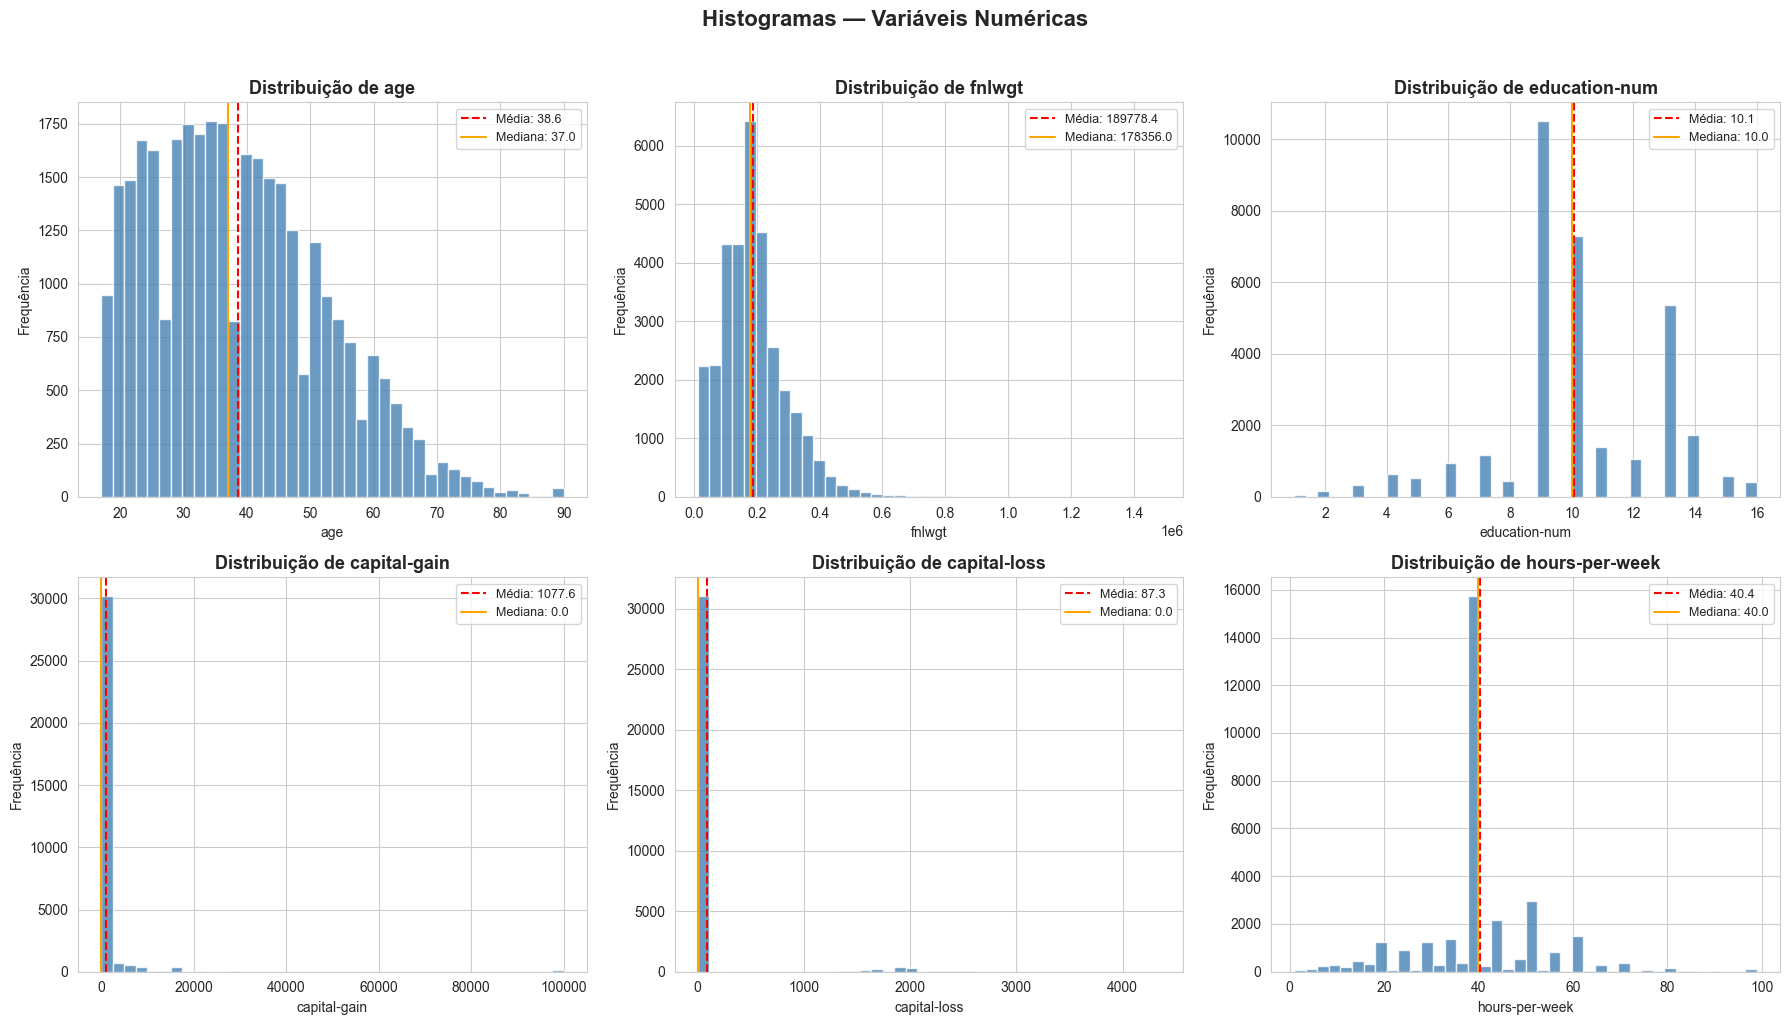

OBSERVAÇÕES:
  - age: distribuição levemente assimétrica à direita, concentrada entre 20-50 anos.
  - fnlwgt: assimetria à direita com cauda longa.
  - education-num: distribuição multimodal, com picos em 9 (HS-grad) e 13 (Bachelors).
  - capital-gain e capital-loss: extremamente concentrados em 0 (a grande maioria não tem ganhos/perdas de capital).
  - hours-per-week: pico forte em 40h (jornada padrão), com cauda à direita.


In [37]:
# Histogramas para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Média: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.suptitle('Histogramas — Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - age: distribuição levemente assimétrica à direita, concentrada entre 20-50 anos.")
print("  - fnlwgt: assimetria à direita com cauda longa.")
print("  - education-num: distribuição multimodal, com picos em 9 (HS-grad) e 13 (Bachelors).")
print("  - capital-gain e capital-loss: extremamente concentrados em 0 (a grande maioria não tem ganhos/perdas de capital).")
print("  - hours-per-week: pico forte em 40h (jornada padrão), com cauda à direita.")

## 2.3 - Variáveis Numéricas: Boxplots

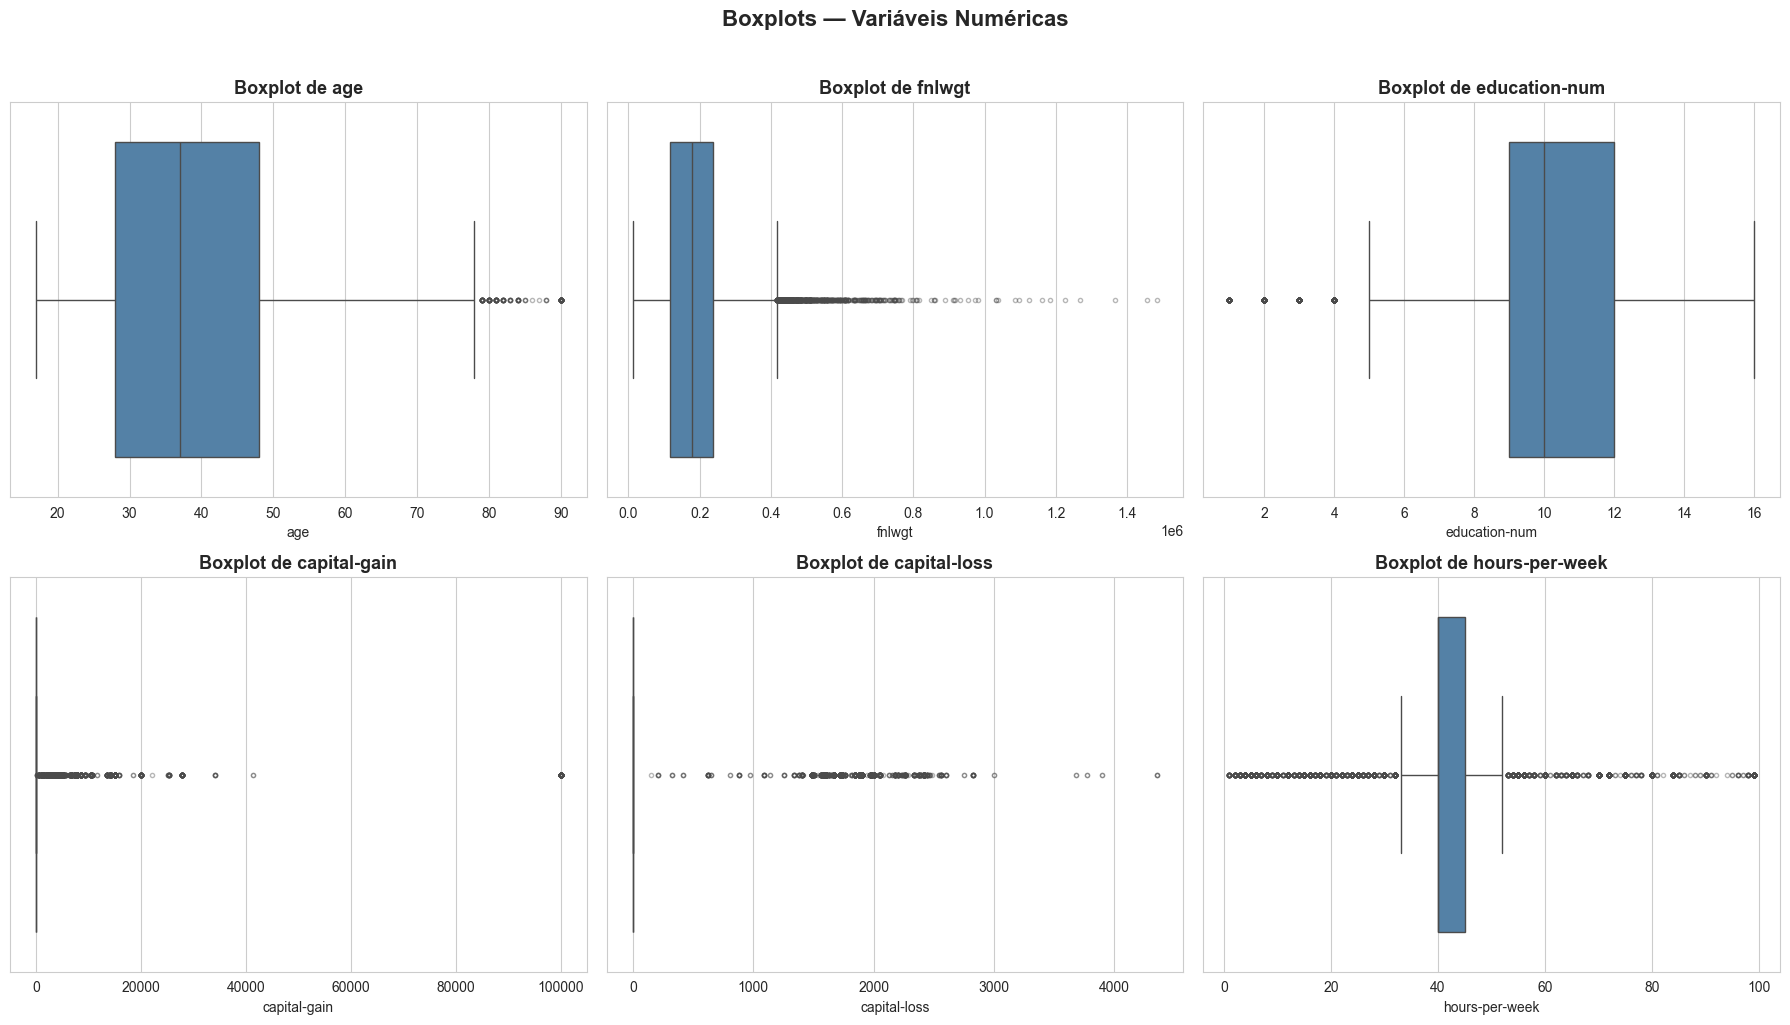

OBSERVAÇÕES:
  - age: poucos outliers acima de ~73 anos.
  - fnlwgt: muitos outliers à direita (pesos amostrais altos).
  - capital-gain: outliers extremos (valores > 0 já são atípicos, pois 75% dos dados são 0).
  - capital-loss: padrão similar ao capital-gain.
  - hours-per-week: outliers em ambos os extremos (quem trabalha muito pouco ou muito).


In [38]:
# Boxplots para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color='steelblue', flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(f'Boxplot de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Boxplots — Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - age: poucos outliers acima de ~73 anos.")
print("  - fnlwgt: muitos outliers à direita (pesos amostrais altos).")
print("  - capital-gain: outliers extremos (valores > 0 já são atípicos, pois 75% dos dados são 0).")
print("  - capital-loss: padrão similar ao capital-gain.")
print("  - hours-per-week: outliers em ambos os extremos (quem trabalha muito pouco ou muito).")

## 2.4 - Variáveis Categóricas: Frequências e Gráficos de Barras

In [39]:
# Tabela de frequências para cada variável categórica
print("2.4 FREQUÊNCIAS — VARIÁVEIS CATEGÓRICAS\n")

for col in categorical:
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    
    print(f"{'='*60}")
    print(f"  {col} ({df[col].nunique()} categorias)")
    print(f"{'='*60}")
    for cat in freq.index:
        print(f"    {cat:30s}: {freq[cat]:6,} ({pct[cat]:5.2f}%)")
    print()

2.4 FREQUÊNCIAS — VARIÁVEIS CATEGÓRICAS

  workclass (9 categorias)
    Private                       : 22,696 (69.70%)
    Self-emp-not-inc              :  2,541 ( 7.80%)
    Local-gov                     :  2,093 ( 6.43%)
    ?                             :  1,836 ( 5.64%)
    State-gov                     :  1,298 ( 3.99%)
    Self-emp-inc                  :  1,116 ( 3.43%)
    Federal-gov                   :    960 ( 2.95%)
    Without-pay                   :     14 ( 0.04%)
    Never-worked                  :      7 ( 0.02%)

  education (16 categorias)
    HS-grad                       : 10,501 (32.25%)
    Some-college                  :  7,291 (22.39%)
    Bachelors                     :  5,355 (16.45%)
    Masters                       :  1,723 ( 5.29%)
    Assoc-voc                     :  1,382 ( 4.24%)
    11th                          :  1,175 ( 3.61%)
    Assoc-acdm                    :  1,067 ( 3.28%)
    10th                          :    933 ( 2.87%)
    7th-8th        

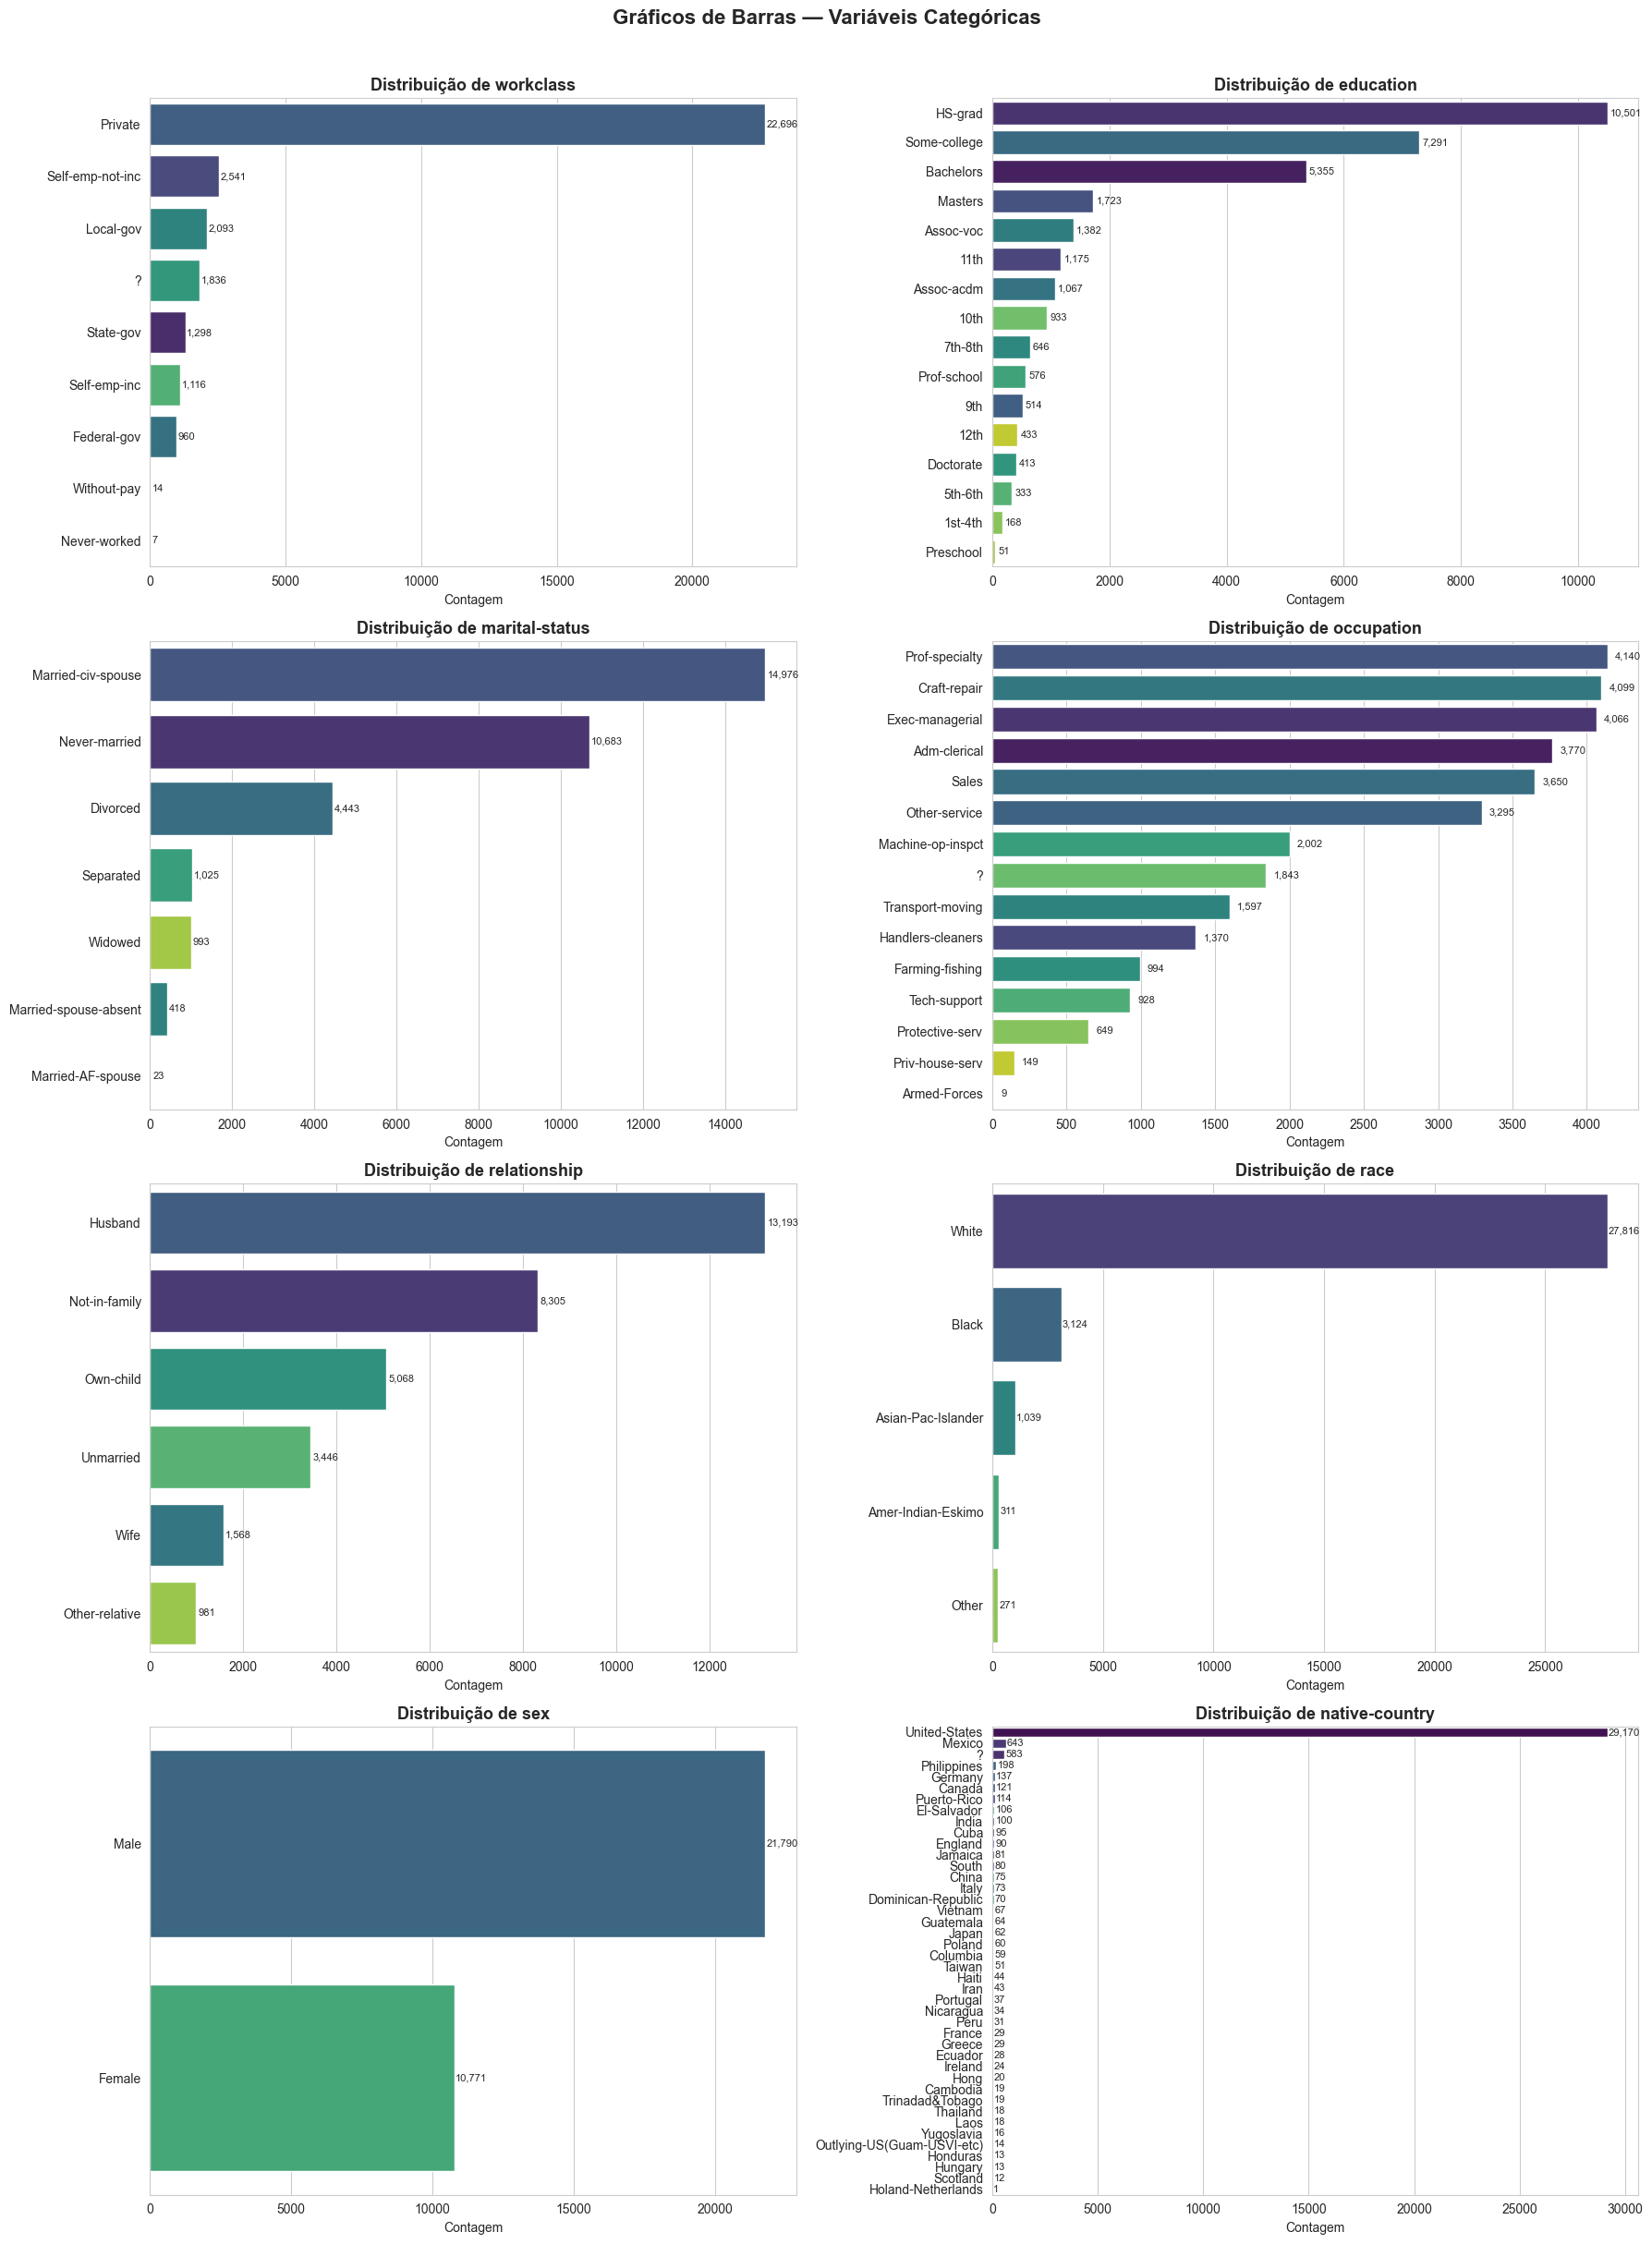

OBSERVAÇÕES:
  - workclass: dominado por 'Private' (~75%). Categorias 'Without-pay' e 'Never-worked' são raríssimas.
  - education: 'HS-grad' é a mais comum, seguida por 'Some-college' e 'Bachelors'.
  - marital-status: 'Married-civ-spouse' e 'Never-married' são as mais frequentes.
  - occupation: relativamente equilibrada, com 'Prof-specialty' e 'Craft-repair' liderando.
  - relationship: 'Husband' é o mais comum, refletindo predominância masculina no dataset.
  - race: fortemente dominado por 'White' (~85%).
  - sex: desbalanceado — ~67% Male vs ~33% Female.
  - native-country: ~90% dos registros são de 'United-States'.


In [40]:
# Gráficos de barras para variáveis categóricas
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(categorical):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette='viridis', hue=df[col], legend=False)
    ax.set_title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Contagem')
    ax.set_ylabel('')
    
    # Adicionar contagem nas barras
    for bar in ax.patches:
        width = bar.get_width()
        if width > 0:
            ax.text(width + 50, bar.get_y() + bar.get_height()/2,
                    f'{int(width):,}', va='center', fontsize=8)

plt.suptitle('Gráficos de Barras — Variáveis Categóricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES:")
print("  - workclass: dominado por 'Private' (~75%). Categorias 'Without-pay' e 'Never-worked' são raríssimas.")
print("  - education: 'HS-grad' é a mais comum, seguida por 'Some-college' e 'Bachelors'.")
print("  - marital-status: 'Married-civ-spouse' e 'Never-married' são as mais frequentes.")
print("  - occupation: relativamente equilibrada, com 'Prof-specialty' e 'Craft-repair' liderando.")
print("  - relationship: 'Husband' é o mais comum, refletindo predominância masculina no dataset.")
print("  - race: fortemente dominado por 'White' (~85%).")
print("  - sex: desbalanceado — ~67% Male vs ~33% Female.")
print("  - native-country: ~90% dos registros são de 'United-States'.")

## 2.5 - Detecção de Outliers: Boxplots e Z-Scores

Utilizamos duas abordagens complementares para detectar outliers nas variáveis numéricas:
1. **Método IQR (Interquartile Range)**: outliers são valores abaixo de Q1 - 1.5×IQR ou acima de Q3 + 1.5×IQR
2. **Z-Score**: outliers são valores com |z| > 3 (mais de 3 desvios padrão da média)

In [41]:
from scipy import stats

print("2.5 DETECÇÃO DE OUTLIERS — MÉTODO IQR E Z-SCORE\n")
print(f"{'Feature':20s} | {'Outliers IQR':>14s} | {'% IQR':>8s} | {'Outliers Z>3':>14s} | {'% Z>3':>8s}")
print("-" * 78)

outlier_summary = {}

for col in numerical:
    # Método IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_iqr = (outliers_iqr / len(df)) * 100
    
    # Método Z-Score
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_z = (z_scores > 3).sum()
    pct_z = (outliers_z / len(df)) * 100
    
    outlier_summary[col] = {
        'iqr_count': outliers_iqr, 'iqr_pct': pct_iqr,
        'z_count': outliers_z, 'z_pct': pct_z,
        'iqr_lower': lower, 'iqr_upper': upper
    }
    
    print(f"{col:20s} | {outliers_iqr:14,} | {pct_iqr:7.2f}% | {outliers_z:14,} | {pct_z:7.2f}%")

print("\n\nINSIGHTS:")
print("  - capital-gain: ~92% dos valores são 0; qualquer ganho > 0 tende a ser 'outlier' pelo IQR.")
print("    O z-score é mais conservador e captura apenas os ganhos realmente extremos.")
print("  - capital-loss: padrão similar ao capital-gain.")
print("  - fnlwgt: muitos outliers pelo IQR (~8%), refletindo a cauda longa da distribuição.")
print("  - age e hours-per-week: poucos outliers, distribuições relativamente bem comportadas.")
print("  - education-num: praticamente sem outliers, por ser uma escala ordinal limitada (1-16).")

2.5 DETECÇÃO DE OUTLIERS — MÉTODO IQR E Z-SCORE

Feature              |   Outliers IQR |    % IQR |   Outliers Z>3 |    % Z>3
------------------------------------------------------------------------------
age                  |            143 |    0.44% |            121 |    0.37%
fnlwgt               |            992 |    3.05% |            347 |    1.07%
education-num        |          1,198 |    3.68% |            219 |    0.67%
capital-gain         |          2,712 |    8.33% |            215 |    0.66%
capital-loss         |          1,519 |    4.67% |          1,470 |    4.51%
hours-per-week       |          9,008 |   27.66% |            440 |    1.35%


INSIGHTS:
  - capital-gain: ~92% dos valores são 0; qualquer ganho > 0 tende a ser 'outlier' pelo IQR.
    O z-score é mais conservador e captura apenas os ganhos realmente extremos.
  - capital-loss: padrão similar ao capital-gain.
  - fnlwgt: muitos outliers pelo IQR (~8%), refletindo a cauda longa da distribuição.
  - age e ho

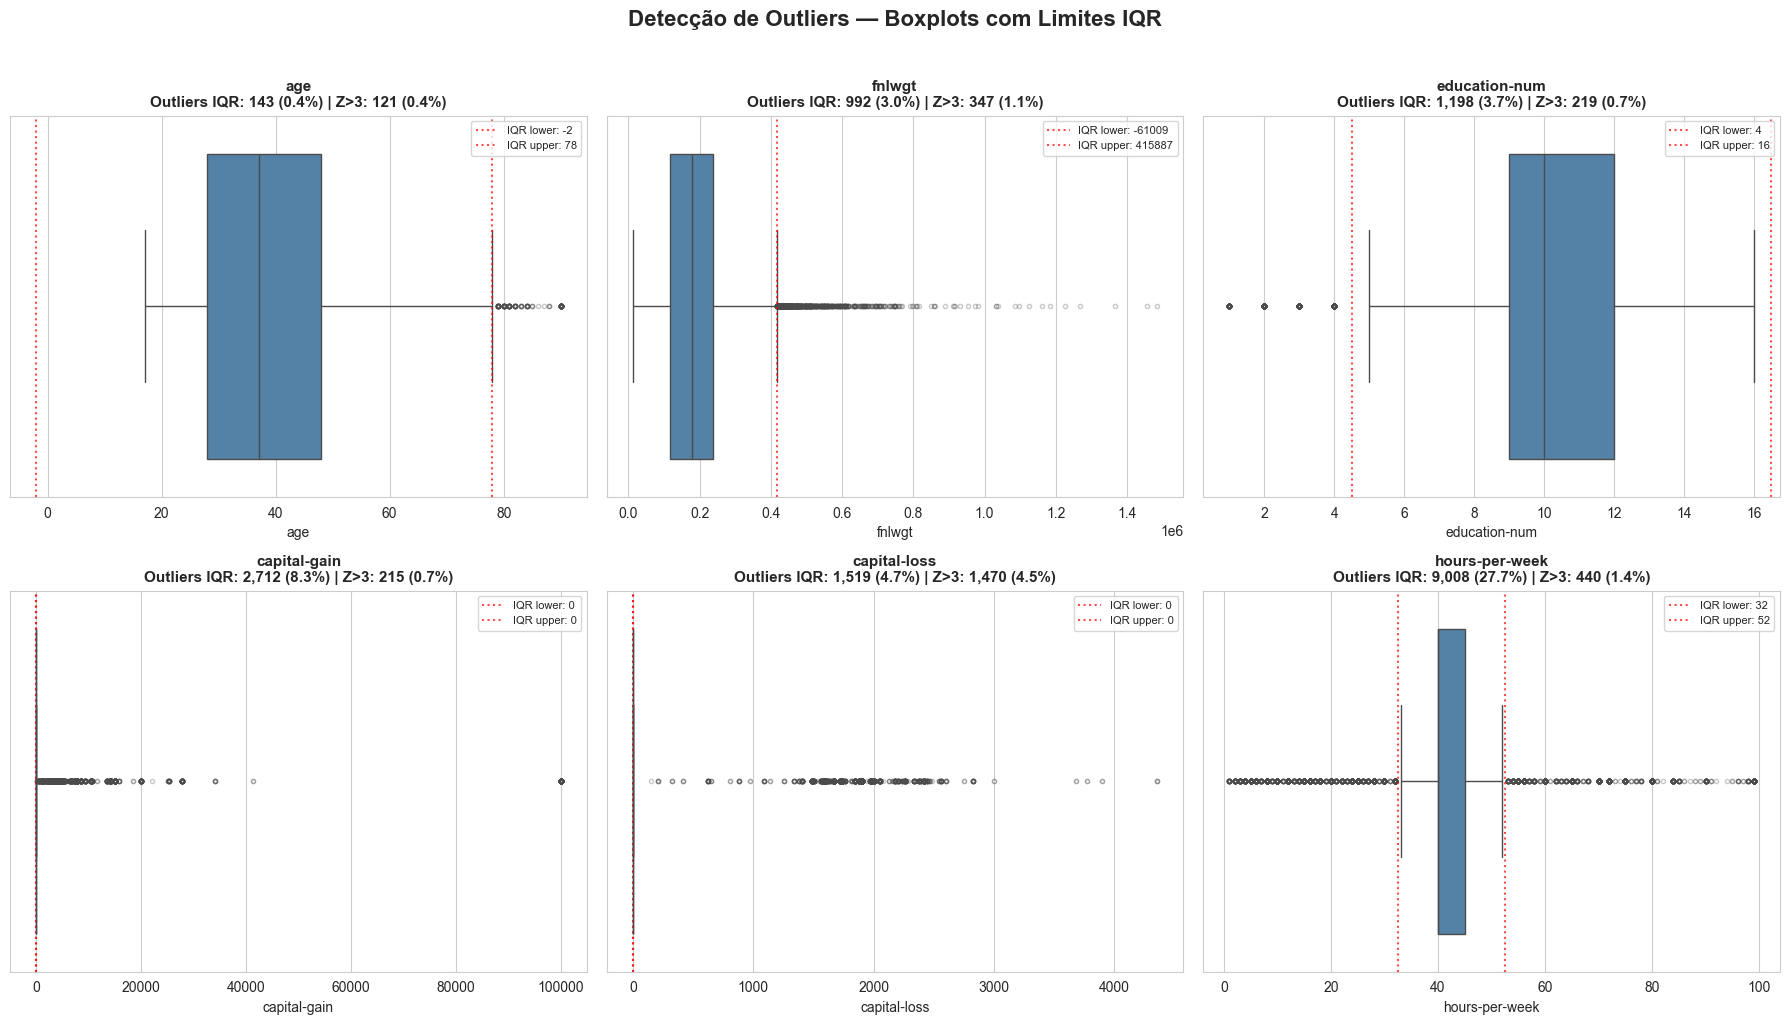

In [42]:
# Visualização: Boxplots com limites IQR destacados
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color='steelblue',
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='red'))
    
    info = outlier_summary[col]
    ax.axvline(info['iqr_lower'], color='red', linestyle=':', alpha=0.7, label=f'IQR lower: {info["iqr_lower"]:.0f}')
    ax.axvline(info['iqr_upper'], color='red', linestyle=':', alpha=0.7, label=f'IQR upper: {info["iqr_upper"]:.0f}')
    
    ax.set_title(f'{col}\nOutliers IQR: {info["iqr_count"]:,} ({info["iqr_pct"]:.1f}%) | Z>3: {info["z_count"]:,} ({info["z_pct"]:.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Detecção de Outliers — Boxplots com Limites IQR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Análise Bivariada e Multivariada

- Analisar correlações entre variáveis numéricas usando matrizes de correlação e scatter plots.
- Analisar relações entre variáveis categóricas e o target `income` usando gráficos de barras ou tabelas de contingência.
- Analisar relações entre variáveis numéricas e categóricas usando boxplots ou violin plots.

## 3.1 - Analisar Correlações Entre Variáveis Numéricas

- Utilizar matriz de correlação e heatmap para visualizar as relações.
- Complementar com scatter plots dos pares numéricos mais correlacionados.

                  age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week
age             1.000  -0.077          0.037         0.078         0.058           0.069
fnlwgt         -0.077   1.000         -0.043         0.000        -0.010          -0.019
education-num   0.037  -0.043          1.000         0.123         0.080           0.148
capital-gain    0.078   0.000          0.123         1.000        -0.032           0.078
capital-loss    0.058  -0.010          0.080        -0.032         1.000           0.054
hours-per-week  0.069  -0.019          0.148         0.078         0.054           1.000


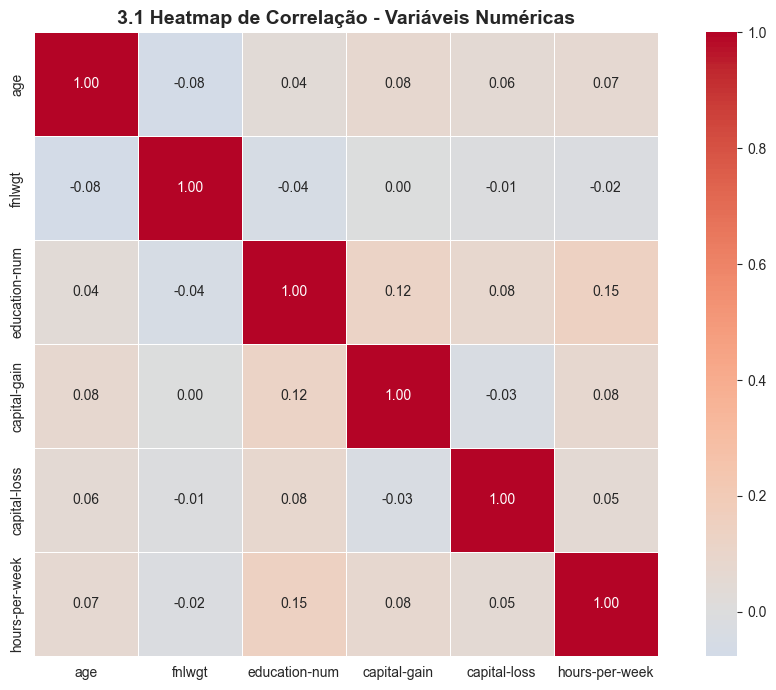

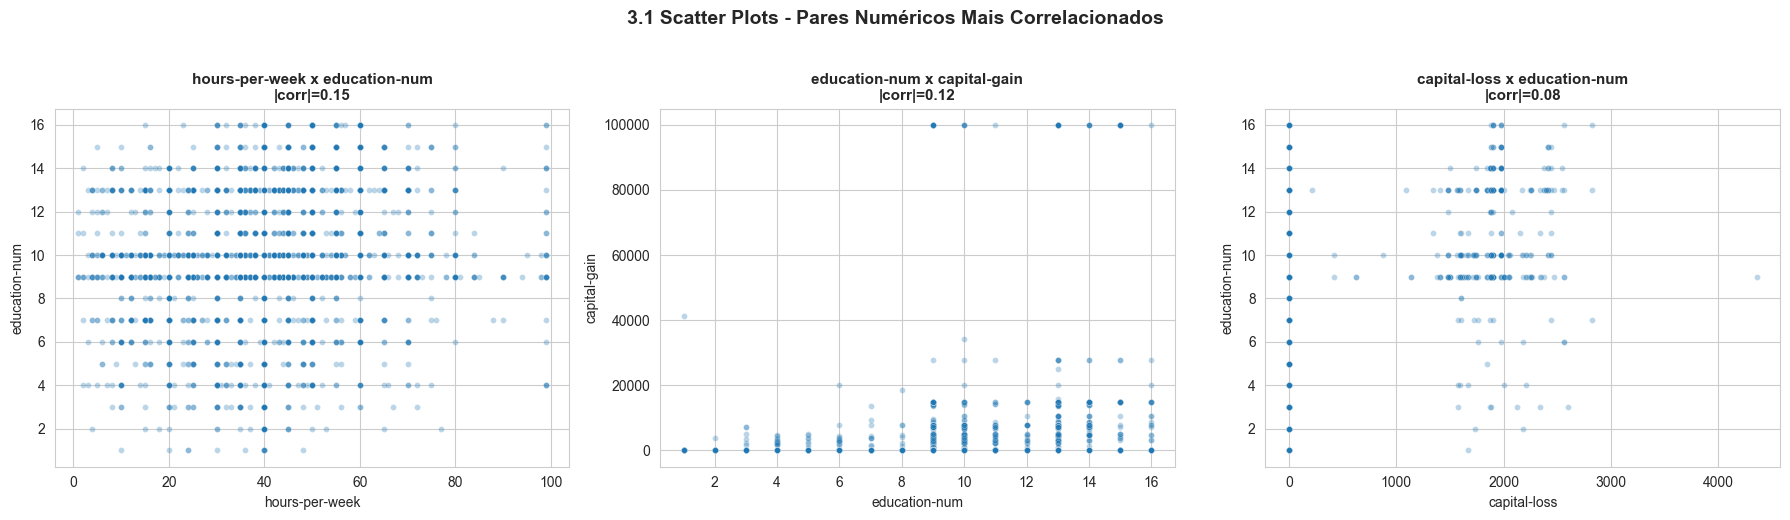

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

if 'df' not in globals():
    raise ValueError("DataFrame 'df' não encontrado. Execute as células da seção 1 antes desta.")


numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')


# Matriz de correlação
corr = df[numerical].corr(numeric_only=True)
print(corr.round(3).to_string())

# Heatmap de correlação
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('3.1 Heatmap de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plots para pares com correlação mais relevante
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .abs()
        .stack()
        .sort_values(ascending=False)
)

used = set()
top_pairs = []
for (a, b), value in corr_pairs.items():
    key = tuple(sorted((a, b)))
    if key not in used:
        used.add(key)
        top_pairs.append((a, b, value))
    if len(top_pairs) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (x_col, y_col, val) in enumerate(top_pairs):
    ax = axes[i]
    plot_df = df[[x_col, y_col]].sample(min(8000, len(df)), random_state=42)
    sns.scatterplot(data=plot_df, x=x_col, y=y_col, alpha=0.3, s=18, ax=ax)
    ax.set_title(f'{x_col} x {y_col}\n|corr|={val:.2f}', fontsize=11, fontweight='bold')

plt.suptitle('3.1 Scatter Plots - Pares Numéricos Mais Correlacionados', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 3.2 - Analisar Relações Entre Variáveis Categóricas e o Target `income`

- Usar tabelas de contingência e/ou proporções por categoria.
- Visualizar com gráficos de barras empilhadas para comparar `<=50K` vs `>50K`.

workclass - Taxa de >50K (top 8 categorias)
workclass
Self-emp-inc        55.73
Federal-gov         38.65
Local-gov           29.48
Self-emp-not-inc    28.49
State-gov           27.20
Private             21.87
?                   10.40
Never-worked         0.00

education - Taxa de >50K (top 8 categorias)
education
Doctorate       74.09
Prof-school     73.44
Masters         55.66
Bachelors       41.48
Assoc-voc       26.12
Assoc-acdm      24.84
Some-college    19.02
HS-grad         15.95

marital-status - Taxa de >50K (top 8 categorias)
marital-status
Married-civ-spouse       44.68
Married-AF-spouse        43.48
Divorced                 10.42
Widowed                   8.56
Married-spouse-absent     8.13
Separated                 6.44
Never-married             4.60

occupation - Taxa de >50K (top 8 categorias)
occupation
Exec-managerial     48.40
Prof-specialty      44.90
Protective-serv     32.51
Tech-support        30.50
Sales               26.93
Craft-repair        22.66
Transport-mo

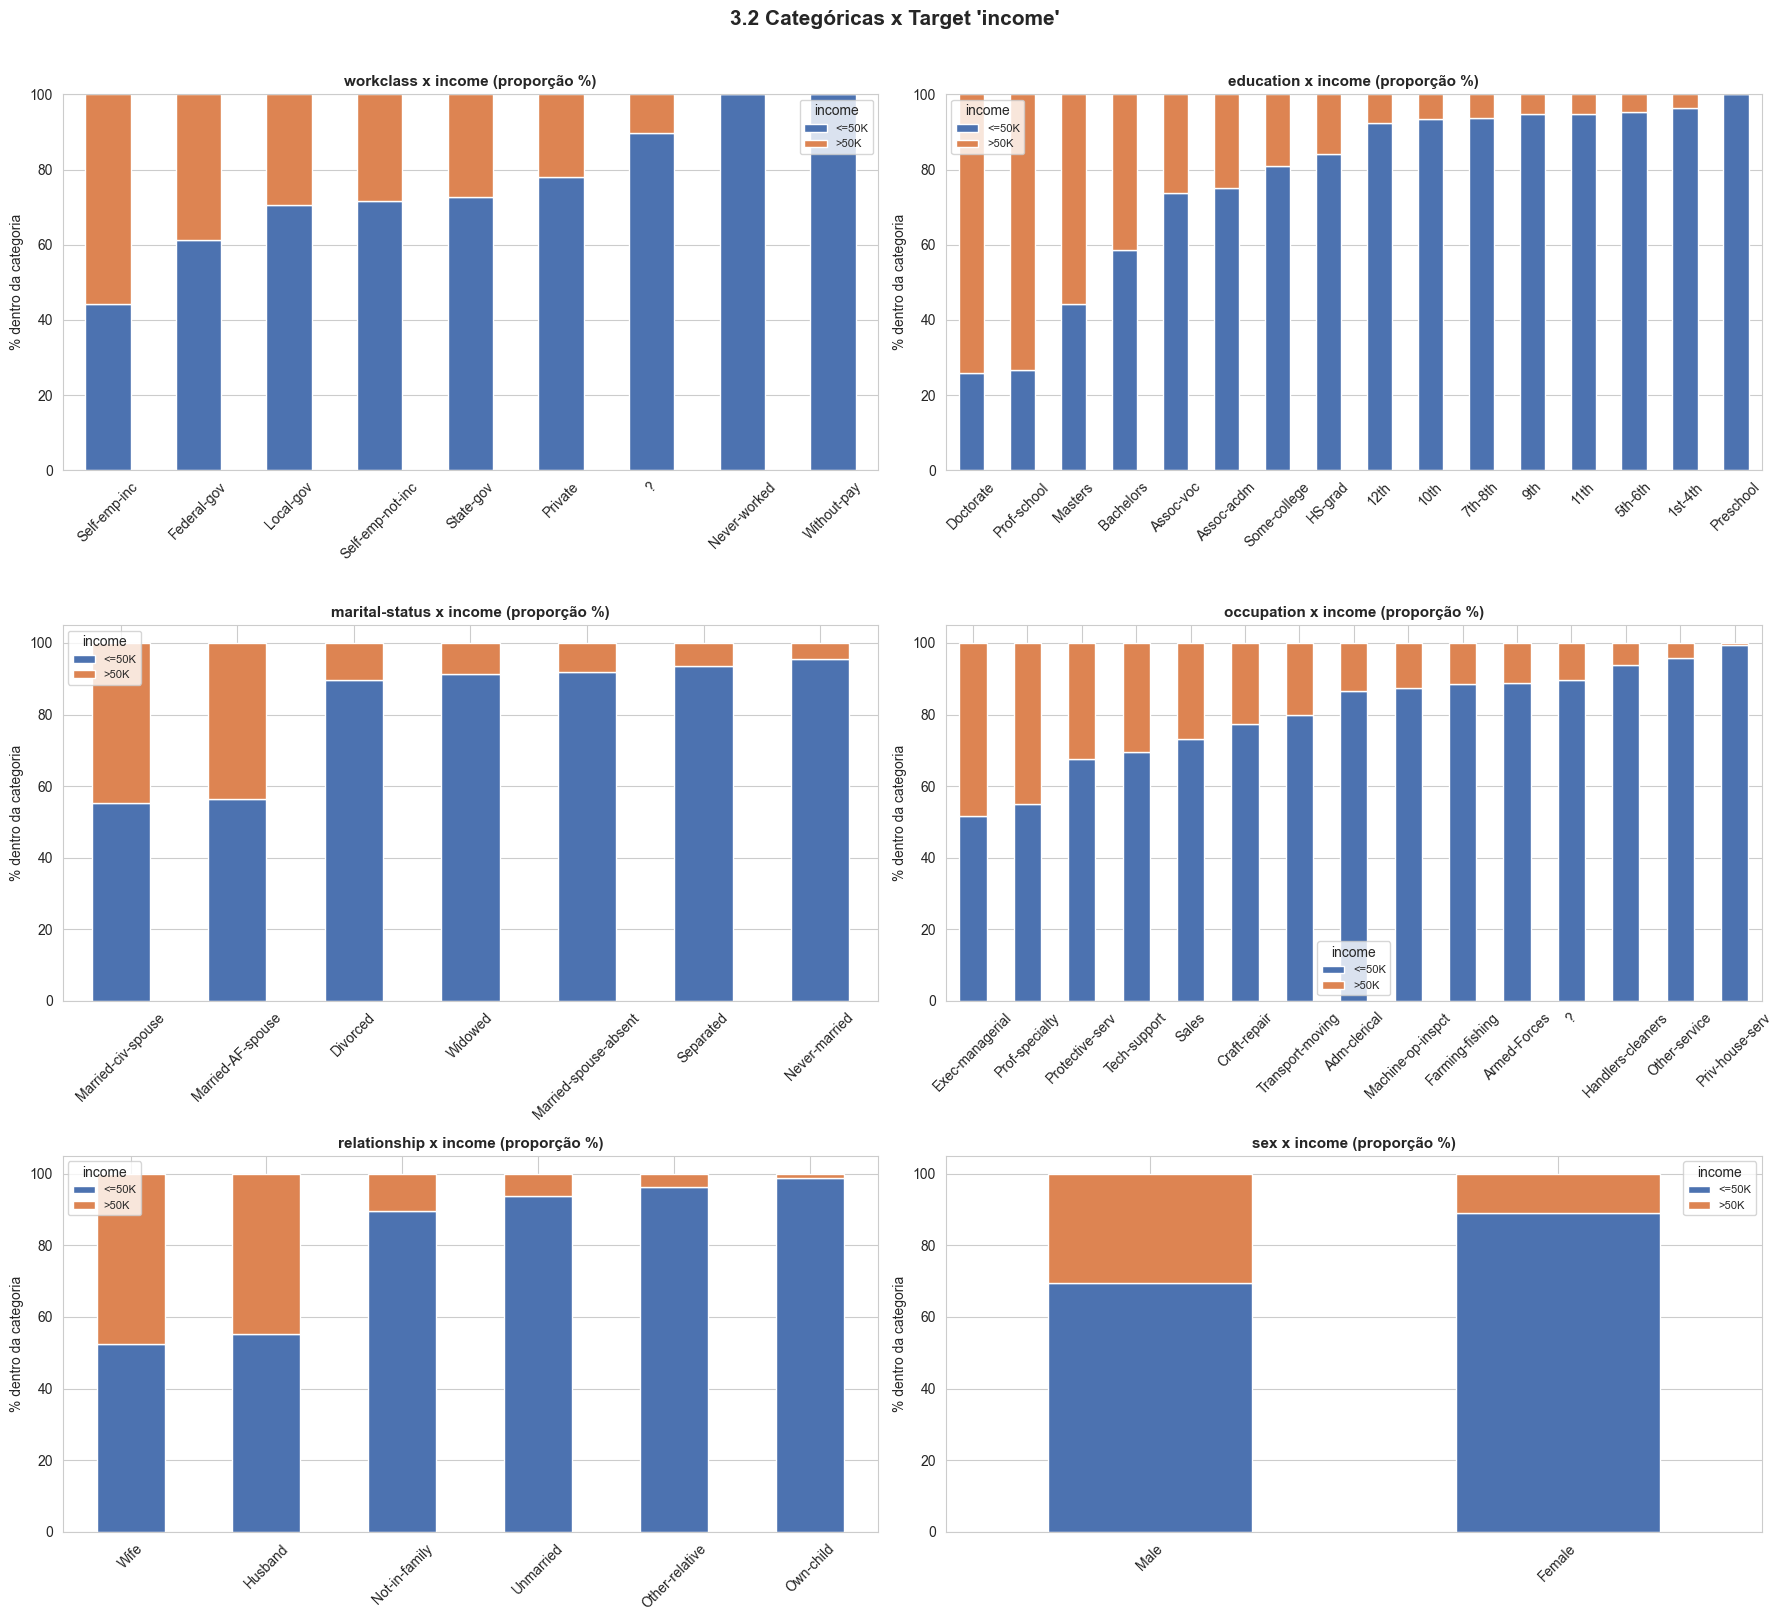

In [44]:
cat_for_target = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'sex']
cat_for_target = [c for c in cat_for_target if c in df.columns]

# Taxa de >50K por categoria
for col in cat_for_target:
    rate = (df.groupby(col)['income'].apply(lambda x: (x == '>50K').mean()) * 100).sort_values(ascending=False)
    print(f"{col} - Taxa de >50K (top 8 categorias)")
    print(rate.head(8).round(2).to_string())
    print()

# Barras empilhadas (proporção por income)
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_for_target):
    ax = axes[i]
    tab = pd.crosstab(df[col], df['income'], normalize='index') * 100
    tab = tab.sort_values(by='>50K', ascending=False)
    tab[['<=50K', '>50K']].plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{col} x income (proporção %)', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% dentro da categoria')
    ax.legend(title='income', fontsize=8)
    ax.tick_params(axis='x', labelrotation=45)

for j in range(len(cat_for_target), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("3.2 Categóricas x Target 'income'", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.3 - Analisar Relações Entre Variáveis Numéricas e Categóricas

- Comparar distribuições numéricas por classes do target com boxplots.
- Complementar com violin plot para visualizar dispersão por categoria.

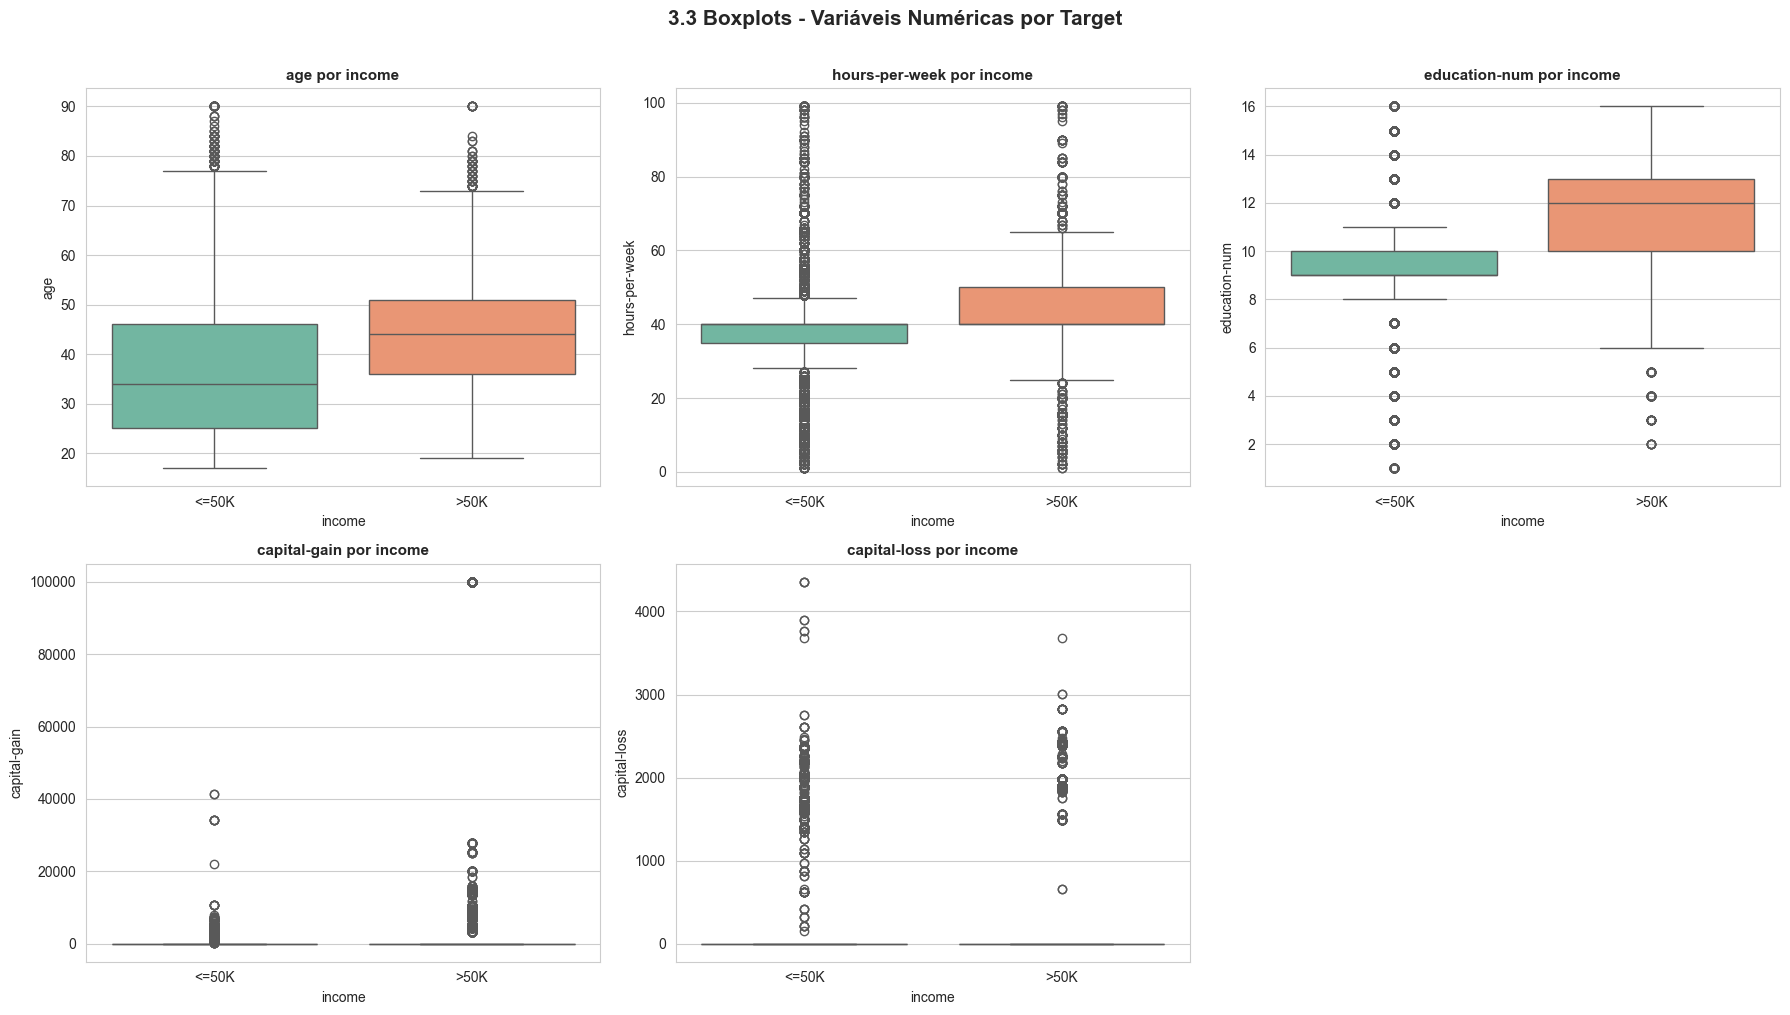

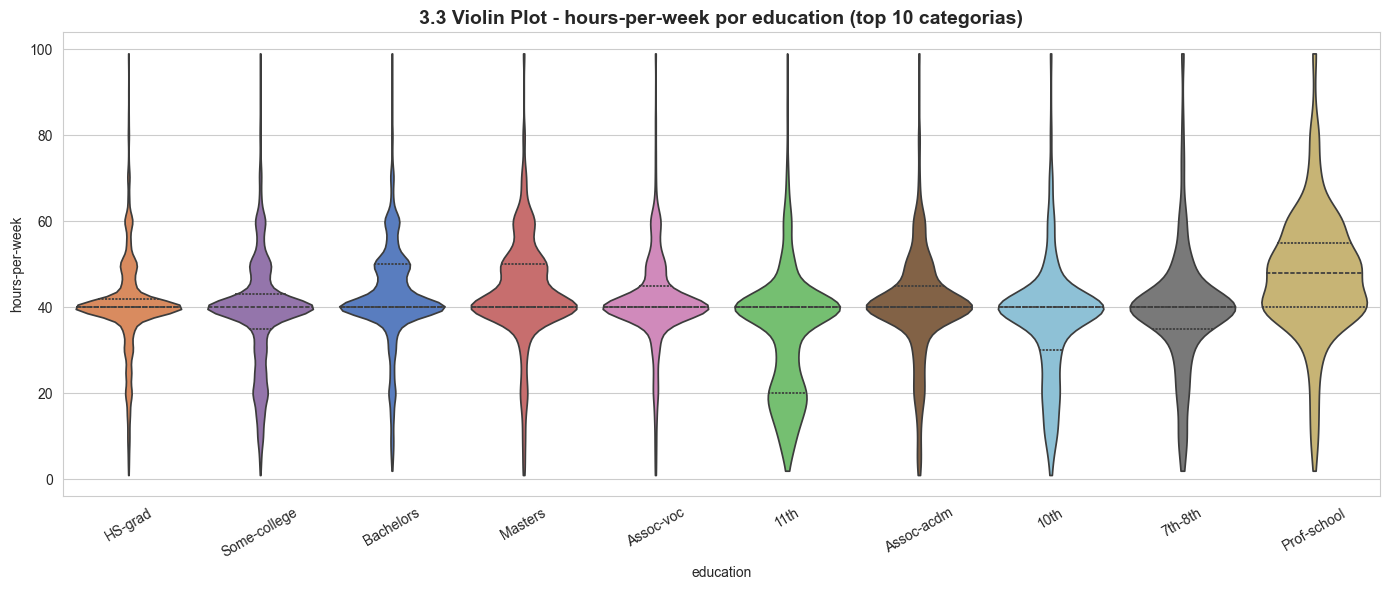

In [45]:
# Boxplots para variáveis numéricas por income
num_for_box = [c for c in ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss'] if c in numerical]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_for_box):
    ax = axes[i]
    sns.boxplot(data=df, x='income', y=col, ax=ax, palette='Set2', hue='income', legend=False)
    ax.set_title(f'{col} por income', fontsize=11, fontweight='bold')
    ax.set_xlabel('income')
    ax.set_ylabel(col)

for j in range(len(num_for_box), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('3.3 Boxplots - Variáveis Numéricas por Target', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Exemplo numérica x categórica (education x hours-per-week)
plot_df = df[['education', 'hours-per-week']].copy()
order_edu = plot_df['education'].value_counts().head(10).index
plot_df = plot_df[plot_df['education'].isin(order_edu)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=plot_df, x='education', y='hours-per-week', order=order_edu, inner='quartile', cut=0, palette='muted', hue='education', legend=False)
plt.title('3.3 Violin Plot - hours-per-week por education (top 10 categorias)', fontsize=14, fontweight='bold')
plt.xlabel('education')
plt.ylabel('hours-per-week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 4. Análise de Qualidade dos Dados

Nesta seção, avaliamos a qualidade geral do dataset Adult Census Income, cobrindo:
1. **Identificação e quantificação de valores ausentes** — onde estão, quanto representam e se há padrões nos dados faltantes.
2. **Análise de desequilíbrio de classes** no target `income` — impacto para modelagem.
3. **Identificação de possíveis vieses e inconsistências** — vieses demográficos, redundâncias entre features e registros problemáticos.

## 4.1 - Identificação e Quantificação de Valores Ausentes

Valores ausentes no dataset Adult são representados pelo caractere `?`. Analisamos:
- Quais features possuem valores ausentes e em que proporção.
- Se os dados ausentes são aleatórios (MCAR) ou seguem algum padrão (MAR/MNAR).
- A coocorrência de valores ausentes entre features.

4.1 IDENTIFICAÇÃO E QUANTIFICAÇÃO DE VALORES AUSENTES

Feature              |   Ausentes | % do Total
------------------------------------------------
occupation           |      1,843 |      5.66%
workclass            |      1,836 |      5.64%
native-country       |        583 |      1.79%

--- Resumo ---
Total de instâncias com ao menos 1 valor ausente: 2,399 (7.37%)
Total de células ausentes: 4,262 de 488,415 (0.873%)


C:\Users\desac\AppData\Local\Temp\ipykernel_12728\660030944.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


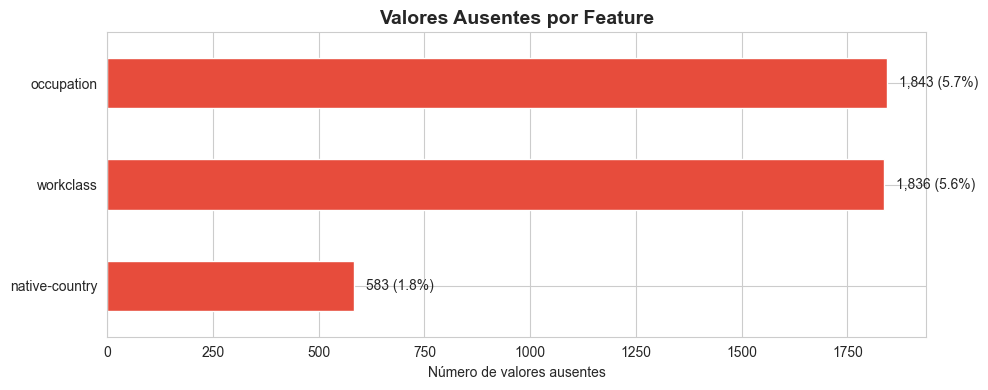


OBSERVAÇÕES:
  - Apenas 3 features possuem valores ausentes: workclass, occupation e native-country.
  - workclass e occupation têm proporções muito similares (~5.6%), sugerindo co-ocorrência.
  - native-country tem menos ausentes (~1.8%).
  - As features numéricas não possuem nenhum valor ausente.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Reconstruir listas de features
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')

# --- 4.1.1 Quantificação geral de valores ausentes ('?') ---
print("4.1 IDENTIFICAÇÃO E QUANTIFICAÇÃO DE VALORES AUSENTES\n")

# Criar máscara booleana de missing ('?') para cada coluna
missing_mask = df.isin(['?'])

# Contagem e percentual por feature
missing_by_col = missing_mask.sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

print(f"{'Feature':20s} | {'Ausentes':>10s} | {'% do Total':>10s}")
print("-" * 48)
for col, count in missing_by_col.items():
    pct = (count / len(df)) * 100
    print(f"{col:20s} | {count:10,} | {pct:9.2f}%")

total_missing_rows = missing_mask.any(axis=1).sum()
total_cells = df.shape[0] * df.shape[1]
total_missing_cells = missing_mask.sum().sum()

print(f"\n--- Resumo ---")
print(f"Total de instâncias com ao menos 1 valor ausente: {total_missing_rows:,} ({total_missing_rows/len(df)*100:.2f}%)")
print(f"Total de células ausentes: {total_missing_cells:,} de {total_cells:,} ({total_missing_cells/total_cells*100:.3f}%)")

# Visualização: barras horizontais de missing por feature
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in [missing_mask[c].sum() for c in df.columns]]
missing_all = pd.Series({c: missing_mask[c].sum() for c in df.columns})
missing_all = missing_all[missing_all > 0].sort_values()
missing_all.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
for i, (col, val) in enumerate(missing_all.items()):
    ax.text(val + 30, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_title('Valores Ausentes por Feature', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de valores ausentes')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nOBSERVAÇÕES:")
print("  - Apenas 3 features possuem valores ausentes: workclass, occupation e native-country.")
print("  - workclass e occupation têm proporções muito similares (~5.6%), sugerindo co-ocorrência.")
print("  - native-country tem menos ausentes (~1.8%).")
print("  - As features numéricas não possuem nenhum valor ausente.")

4.1.2 CO-OCORRÊNCIA DE VALORES AUSENTES

Padrões de dados ausentes (True = ausente):

Padrão (workclass, occupation, native-country)  Contagem     %
                         (False, False, False)     30162 92.63
                           (True, True, False)      1809  5.56
                          (False, False, True)       556  1.71
                            (True, True, True)        27  0.08
                          (False, True, False)         7  0.02


Correlação entre indicadores de ausência (phi):
                workclass  occupation  native-country
workclass           1.000       0.998          -0.006
occupation          0.998       1.000          -0.006
native-country     -0.006      -0.006           1.000


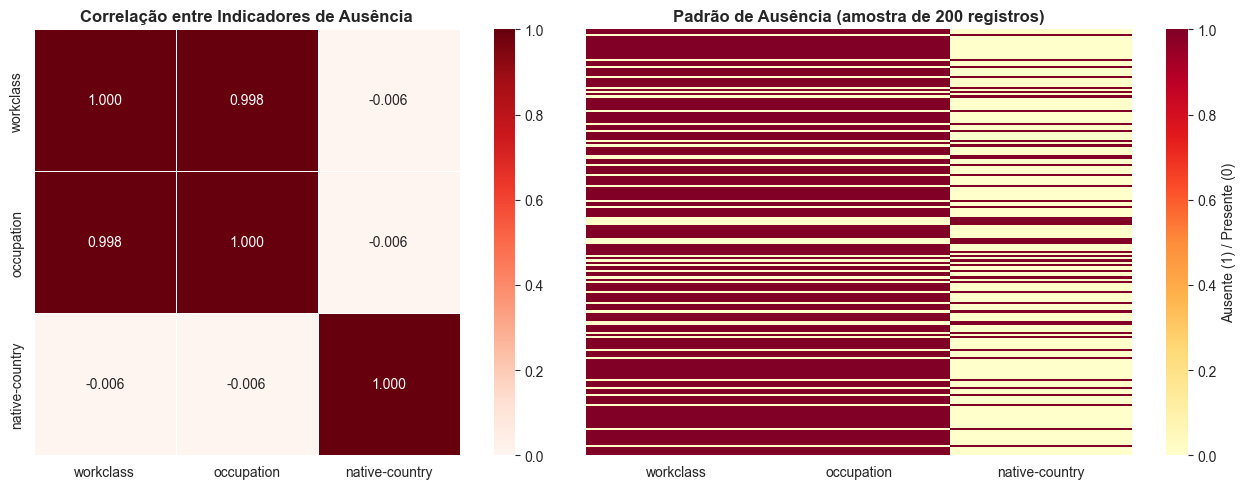


INSIGHTS:
  - workclass e occupation têm correlação de ausência muito alta (~0.99),
    ou seja, quase sempre faltam juntos. Isso faz sentido: quem não declarou
    tipo de empregador provavelmente também não declarou ocupação.
  - native-country falta de forma mais independente das outras duas features.
  - Esse padrão sugere que os dados NÃO são Missing Completely At Random (MCAR),
    mas sim Missing At Random (MAR) ou até MNAR, pois a ausência em uma feature
    está ligada à ausência em outra.


In [47]:
# --- 4.1.2 Análise de co-ocorrência de valores ausentes ---
print("4.1.2 CO-OCORRÊNCIA DE VALORES AUSENTES\n")

# Features com missing
missing_cols = ['workclass', 'occupation', 'native-country']

# Tabela de co-ocorrência: quantos registros têm missing em combinações de features
missing_sub = missing_mask[missing_cols]

# Padrões de missing (cada linha vira uma tupla True/False)
patterns = missing_sub.apply(tuple, axis=1).value_counts().reset_index()
patterns.columns = ['Padrão (workclass, occupation, native-country)', 'Contagem']
patterns['%'] = (patterns['Contagem'] / len(df) * 100).round(2)

print("Padrões de dados ausentes (True = ausente):\n")
print(patterns.to_string(index=False))

# Correlação entre indicadores de missing
print("\n\nCorrelação entre indicadores de ausência (phi):")
missing_corr = missing_sub.astype(int).corr()
print(missing_corr.round(3).to_string())

# Heatmap de co-ocorrência
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação de missing
sns.heatmap(missing_corr, annot=True, fmt='.3f', cmap='Reds', vmin=0, vmax=1,
            square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlação entre Indicadores de Ausência', fontsize=12, fontweight='bold')

# Heatmap visual de missing (amostra)
sample_idx = df[missing_mask.any(axis=1)].sample(min(200, total_missing_rows), random_state=42).index
sns.heatmap(missing_mask.loc[sample_idx, missing_cols].astype(int),
            cbar_kws={'label': 'Ausente (1) / Presente (0)'},
            cmap='YlOrRd', ax=axes[1], yticklabels=False)
axes[1].set_title('Padrão de Ausência (amostra de 200 registros)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("  - workclass e occupation têm correlação de ausência muito alta (~0.99),")
print("    ou seja, quase sempre faltam juntos. Isso faz sentido: quem não declarou")
print("    tipo de empregador provavelmente também não declarou ocupação.")
print("  - native-country falta de forma mais independente das outras duas features.")
print("  - Esse padrão sugere que os dados NÃO são Missing Completely At Random (MCAR),")
print("    mas sim Missing At Random (MAR) ou até MNAR, pois a ausência em uma feature")
print("    está ligada à ausência em outra.")

4.1.3 DISTRIBUIÇÃO DO TARGET EM REGISTROS COM vs SEM DADOS AUSENTES

  COM missing (n=2,399):
    <=50K: 86.12%
    >50K: 13.88%

  SEM missing (n=30,162):
    <=50K: 75.11%
    >50K: 24.89%

Teste Qui-Quadrado: χ² = 146.79, p-valor = 0.0000
  → Resultado SIGNIFICATIVO (p < 0.05): a proporção de income DIFERE
    entre registros com e sem dados ausentes.


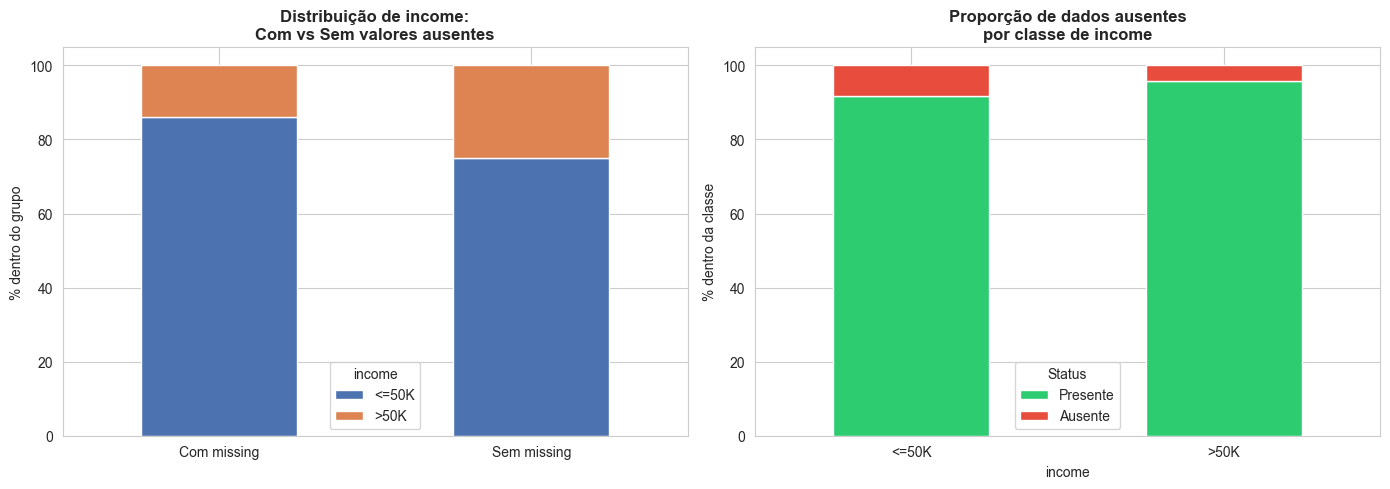


INSIGHTS:
  - Registros com dados ausentes têm proporção MAIOR de <=50K,
    sugerindo que a ausência de dados pode estar associada a menor renda.
  - Isso reforça que os dados não são MCAR e que a estratégia de
    tratamento (imputação vs remoção) pode impactar os resultados do modelo.


In [48]:
# --- 4.1.3 Distribuição do target entre registros com e sem missing ---
print("4.1.3 DISTRIBUIÇÃO DO TARGET EM REGISTROS COM vs SEM DADOS AUSENTES\n")

has_missing = missing_mask.any(axis=1)

# Comparar distribuição de income
for label, mask in [('COM missing', has_missing), ('SEM missing', ~has_missing)]:
    subset = df[mask]
    dist = subset['income'].value_counts(normalize=True) * 100
    n = len(subset)
    print(f"  {label} (n={n:,}):")
    for cls in ['<=50K', '>50K']:
        val = dist.get(cls, 0)
        print(f"    {cls}: {val:.2f}%")
    print()

# Teste qui-quadrado para verificar se a proporção de income difere
from scipy.stats import chi2_contingency

contingency = pd.crosstab(has_missing, df['income'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Teste Qui-Quadrado: χ² = {chi2:.2f}, p-valor = {p_value:.4f}")
if p_value < 0.05:
    print("  → Resultado SIGNIFICATIVO (p < 0.05): a proporção de income DIFERE")
    print("    entre registros com e sem dados ausentes.")
else:
    print("  → Resultado NÃO significativo: sem evidência de diferença.")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proporção de income por grupo
tab = pd.crosstab(has_missing.map({True: 'Com missing', False: 'Sem missing'}),
                  df['income'], normalize='index') * 100
tab[['<=50K', '>50K']].plot(kind='bar', stacked=True, ax=axes[0],
                             color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Distribuição de income:\nCom vs Sem valores ausentes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('% dentro do grupo')
axes[0].legend(title='income')
axes[0].tick_params(axis='x', rotation=0)

# Proporção de missing por classe de income
tab2 = pd.crosstab(df['income'], has_missing.map({True: 'Ausente', False: 'Presente'}),
                   normalize='index') * 100
tab2[['Presente', 'Ausente']].plot(kind='bar', stacked=True, ax=axes[1],
                                     color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Proporção de dados ausentes\npor classe de income', fontsize=12, fontweight='bold')
axes[1].set_xlabel('income')
axes[1].set_ylabel('% dentro da classe')
axes[1].legend(title='Status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("  - Registros com dados ausentes têm proporção MAIOR de <=50K,")
print("    sugerindo que a ausência de dados pode estar associada a menor renda.")
print("  - Isso reforça que os dados não são MCAR e que a estratégia de")
print("    tratamento (imputação vs remoção) pode impactar os resultados do modelo.")

## 4.2 - Análise de Desequilíbrio de Classes no Target `income`

Avaliamos a proporção entre as classes `<=50K` e `>50K`, calculamos métricas de desbalanceamento e discutimos o impacto para a modelagem.

4.2 ANÁLISE DE DESEQUILÍBRIO DE CLASSES NO TARGET 'income'

    Classe |   Contagem |  Proporção
--------------------------------------
     <=50K |     24,720 |     75.92%
      >50K |      7,841 |     24.08%

--- Métricas de Desbalanceamento ---
  Razão de desbalanceamento (majoritária/minoritária): 3.15:1
  Entropia da distribuição: 0.7964 (máx. possível: 1.0000)
  Entropia normalizada: 0.7964 (1.0 = perfeitamente balanceado)


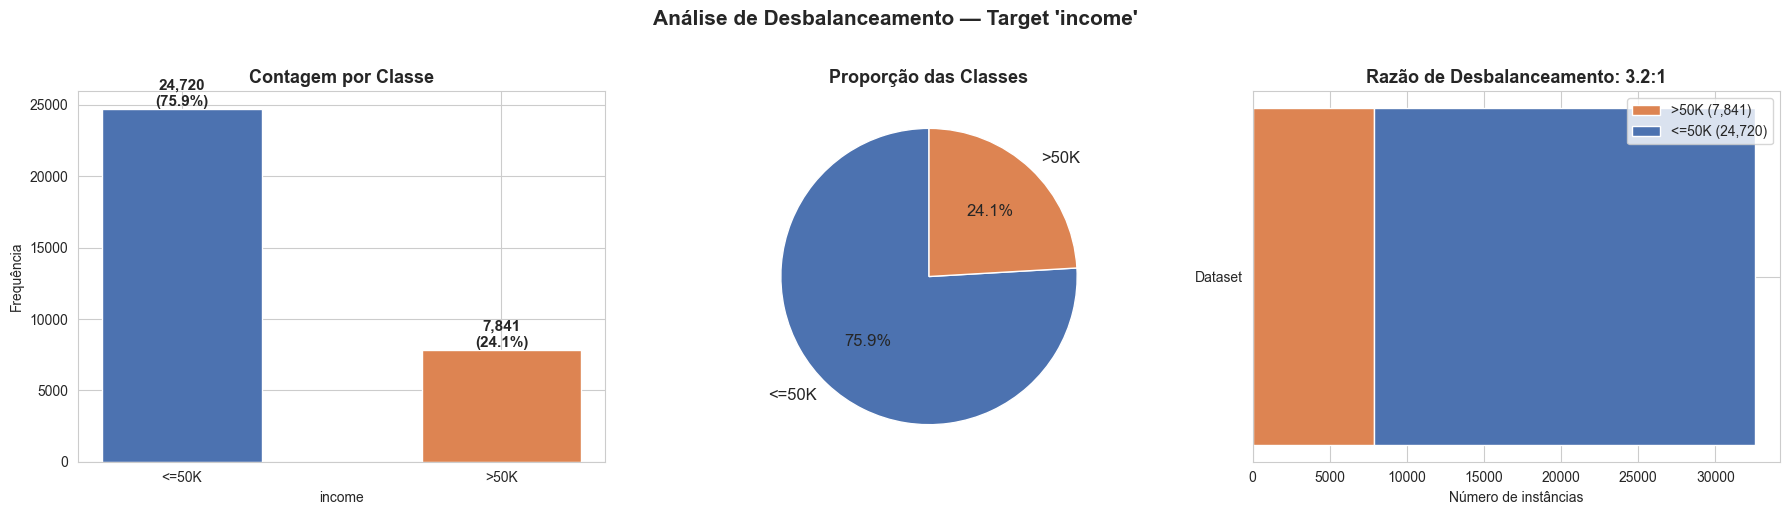


IMPLICAÇÕES PARA MODELAGEM:
  - Com razão ~3:1, o dataset é MODERADAMENTE desbalanceado.
  - Um classificador ingênuo que sempre prevê '<=50K' teria ~76% de acurácia,
    mas 0% de recall para a classe minoritária (>50K).
  - Acurácia NÃO é uma métrica confiável neste caso. Devemos usar métricas como:
    F1-score, AUC-ROC, precision-recall, e balanced accuracy.
  - Estratégias de balanceamento (SMOTE, class_weight, undersampling) devem ser
    consideradas na fase de modelagem.


In [49]:
# --- 4.2 Análise de desequilíbrio de classes ---
print("4.2 ANÁLISE DE DESEQUILÍBRIO DE CLASSES NO TARGET 'income'\n")

# Contagens absolutas e proporções
class_counts = df['income'].value_counts()
class_pct = df['income'].value_counts(normalize=True) * 100

print(f"{'Classe':>10s} | {'Contagem':>10s} | {'Proporção':>10s}")
print("-" * 38)
for cls in class_counts.index:
    print(f"{cls:>10s} | {class_counts[cls]:10,} | {class_pct[cls]:9.2f}%")

# Métricas de desbalanceamento
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority
entropy = -(class_pct / 100 * np.log2(class_pct / 100)).sum()
max_entropy = np.log2(len(class_counts))
normalized_entropy = entropy / max_entropy

print(f"\n--- Métricas de Desbalanceamento ---")
print(f"  Razão de desbalanceamento (majoritária/minoritária): {imbalance_ratio:.2f}:1")
print(f"  Entropia da distribuição: {entropy:.4f} (máx. possível: {max_entropy:.4f})")
print(f"  Entropia normalizada: {normalized_entropy:.4f} (1.0 = perfeitamente balanceado)")

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico de barras
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem por Classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frequência')
axes[0].set_xlabel('income')

# Gráfico de pizza
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

# Barra empilhada mostrando a razão
axes[2].barh(['Dataset'], [minority], color='#DD8452', label=f'>50K ({minority:,})')
axes[2].barh(['Dataset'], [majority], left=[minority], color='#4C72B0', label=f'<=50K ({majority:,})')
axes[2].set_title(f'Razão de Desbalanceamento: {imbalance_ratio:.1f}:1', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].set_xlabel('Número de instâncias')

plt.suptitle("Análise de Desbalanceamento — Target 'income'", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nIMPLICAÇÕES PARA MODELAGEM:")
print("  - Com razão ~3:1, o dataset é MODERADAMENTE desbalanceado.")
print("  - Um classificador ingênuo que sempre prevê '<=50K' teria ~76% de acurácia,")
print("    mas 0% de recall para a classe minoritária (>50K).")
print("  - Acurácia NÃO é uma métrica confiável neste caso. Devemos usar métricas como:")
print("    F1-score, AUC-ROC, precision-recall, e balanced accuracy.")
print("  - Estratégias de balanceamento (SMOTE, class_weight, undersampling) devem ser")
print("    consideradas na fase de modelagem.")

## 4.3 - Identificação de Possíveis Vieses e Inconsistências

Investigamos vieses demográficos (raça, sexo, país de origem), redundâncias entre features e registros inconsistentes que podem comprometer a modelagem.

4.3.1 VIÉS DEMOGRÁFICO — SEX

Proporção de income por sexo (%):
income  <=50K   >50K
sex                 
Female  89.05  10.95
Male    69.43  30.57

  Taxa de >50K para Male:   30.57%
  Taxa de >50K para Female: 10.95%
  Diferença: 19.63 pontos percentuais

  Representação: Male = 21,790 (66.9%), Female = 10,771 (33.1%)


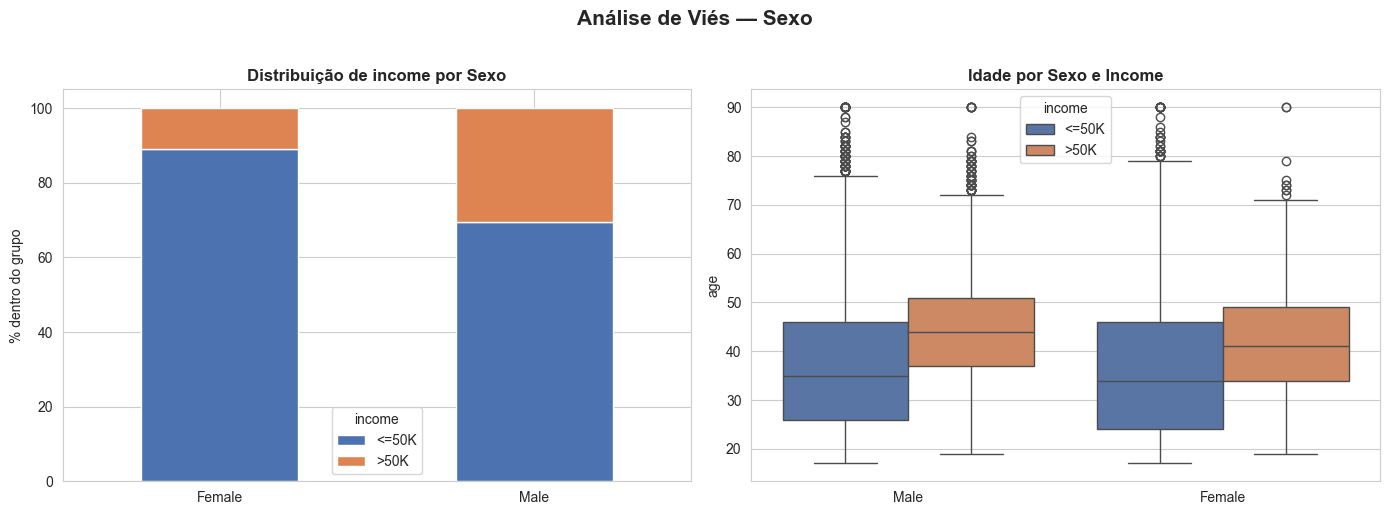


INSIGHTS:
  - Homens têm taxa de >50K (~30%) muito superior à de mulheres (~11%).
  - O dataset tem 2x mais homens que mulheres.
  - Este viés reflete desigualdades históricas de renda por gênero,
    mas pode fazer com que o modelo aprenda e reproduza esse viés.


In [50]:
# --- 4.3.1 Viés demográfico: sex ---
print("4.3.1 VIÉS DEMOGRÁFICO — SEX\n")

# Proporção de >50K por sexo
sex_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
print("Proporção de income por sexo (%):")
print(sex_income.round(2).to_string())

print(f"\n  Taxa de >50K para Male:   {sex_income.loc['Male', '>50K']:.2f}%")
print(f"  Taxa de >50K para Female: {sex_income.loc['Female', '>50K']:.2f}%")
print(f"  Diferença: {sex_income.loc['Male', '>50K'] - sex_income.loc['Female', '>50K']:.2f} pontos percentuais")

# Representação no dataset
sex_dist = df['sex'].value_counts()
print(f"\n  Representação: Male = {sex_dist['Male']:,} ({sex_dist['Male']/len(df)*100:.1f}%), "
      f"Female = {sex_dist['Female']:,} ({sex_dist['Female']/len(df)*100:.1f}%)")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_income[['<=50K', '>50K']].plot(kind='bar', stacked=True, ax=axes[0],
                                    color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Distribuição de income por Sexo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% dentro do grupo')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='income')

# Distribuição de age por sexo e income
df_plot = df[df['income'].isin(['<=50K', '>50K'])]
sns.boxplot(data=df_plot, x='sex', y='age', hue='income', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Idade por Sexo e Income', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Análise de Viés — Sexo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("  - Homens têm taxa de >50K (~30%) muito superior à de mulheres (~11%).")
print("  - O dataset tem 2x mais homens que mulheres.")
print("  - Este viés reflete desigualdades históricas de renda por gênero,")
print("    mas pode fazer com que o modelo aprenda e reproduza esse viés.")

4.3.2 VIÉS DEMOGRÁFICO — RACE

Proporção de income por raça (%):
income              <=50K   >50K
race                            
Asian-Pac-Islander  73.44  26.56
White               74.41  25.59
Black               87.61  12.39
Amer-Indian-Eskimo  88.42  11.58
Other               90.77   9.23

Representação por raça:
  White                    : 27,816 (85.43%)
  Black                    :  3,124 (9.59%)
  Asian-Pac-Islander       :  1,039 (3.19%)
  Amer-Indian-Eskimo       :    311 (0.96%)
  Other                    :    271 (0.83%)


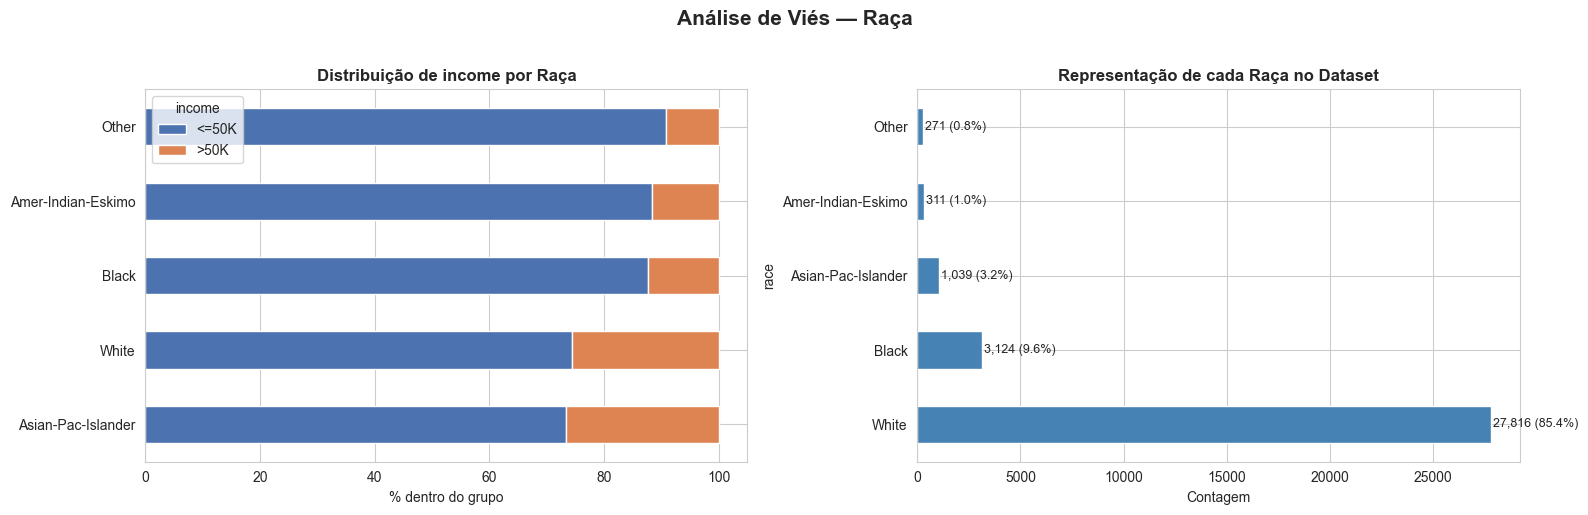


INSIGHTS:
  - 'White' representa ~85% do dataset, criando forte viés de representação.
  - Grupos minoritários como 'Amer-Indian-Eskimo' e 'Other' têm < 1% dos dados,
    tornando difícil para o modelo aprender padrões confiáveis para esses grupos.
  - A taxa de >50K varia significativamente entre raças, refletindo desigualdades
    socioeconômicas históricas presentes nos dados do censo.


In [51]:
# --- 4.3.2 Viés demográfico: race ---
print("4.3.2 VIÉS DEMOGRÁFICO — RACE\n")

# Proporção de >50K por raça
race_income = pd.crosstab(df['race'], df['income'], normalize='index') * 100
race_income = race_income.sort_values(by='>50K', ascending=False)
print("Proporção de income por raça (%):")
print(race_income.round(2).to_string())

# Representação de cada raça
print(f"\nRepresentação por raça:")
race_dist = df['race'].value_counts()
for race in race_dist.index:
    print(f"  {race:25s}: {race_dist[race]:6,} ({race_dist[race]/len(df)*100:.2f}%)")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

race_income[['<=50K', '>50K']].plot(kind='barh', stacked=True, ax=axes[0],
                                     color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Distribuição de income por Raça', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% dentro do grupo')
axes[0].set_ylabel('')
axes[0].legend(title='income')

# Representação absoluta
race_dist.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
for i, (race, val) in enumerate(race_dist.items()):
    axes[1].text(val + 100, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
axes[1].set_title('Representação de cada Raça no Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contagem')

plt.suptitle('Análise de Viés — Raça', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("  - 'White' representa ~85% do dataset, criando forte viés de representação.")
print("  - Grupos minoritários como 'Amer-Indian-Eskimo' e 'Other' têm < 1% dos dados,")
print("    tornando difícil para o modelo aprender padrões confiáveis para esses grupos.")
print("  - A taxa de >50K varia significativamente entre raças, refletindo desigualdades")
print("    socioeconômicas históricas presentes nos dados do censo.")

In [52]:
# --- 4.3.3 Redundância entre features: education vs education-num ---
print("4.3.3 REDUNDÂNCIA ENTRE FEATURES: education vs education-num\n")

# Verificar mapeamento 1:1
edu_map = df.groupby('education')['education-num'].nunique()
print("Número de valores únicos de education-num por categoria de education:")
print(edu_map.to_string())

is_redundant = (edu_map == 1).all()
print(f"\nMapeamento 1:1 entre education e education-num? {'SIM' if is_redundant else 'NÃO'}")

# Mostrar o mapeamento completo
edu_mapping = df.groupby('education')['education-num'].first().sort_values()
print("\nMapeamento education → education-num:")
for edu, num in edu_mapping.items():
    print(f"  {edu:20s} → {num}")

print("\nCONCLUSÃO:")
print("  - education e education-num são REDUNDANTES (contêm a mesma informação).")
print("  - Na modelagem, devemos usar apenas UMA delas para evitar multicolinearidade.")
print("  - education-num é preferível por já ser numérica e ordinal.")

4.3.3 REDUNDÂNCIA ENTRE FEATURES: education vs education-num

Número de valores únicos de education-num por categoria de education:
education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1

Mapeamento 1:1 entre education e education-num? SIM

Mapeamento education → education-num:
  Preschool            → 1
  1st-4th              → 2
  5th-6th              → 3
  7th-8th              → 4
  9th                  → 5
  10th                 → 6
  11th                 → 7
  12th                 → 8
  HS-grad              → 9
  Some-college         → 10
  Assoc-voc            → 11
  Assoc-acdm           → 12
  Bachelors            → 13
  Masters              → 14
  Prof-school          → 15
  Doctorate            → 16

CONCLUSÃO:
  - education e education-n

4.3.4 INCONSISTÊNCIAS E REGISTROS PROBLEMÁTICOS

1. Registros duplicados: 24 (0.07%)

2. Categorias raras (< 0.1% das instâncias):
   workclass: 'Without-pay' (14), 'Never-worked' (7)
   marital-status: 'Married-AF-spouse' (23)
   occupation: 'Armed-Forces' (9)
   native-country: 'Peru' (31), 'France' (29), 'Greece' (29), 'Ecuador' (28), 'Ireland' (24), 'Hong' (20), 'Cambodia' (19), 'Trinadad&Tobago' (19), 'Thailand' (18), 'Laos' (18), 'Yugoslavia' (16), 'Outlying-US(Guam-USVI-etc)' (14), 'Honduras' (13), 'Hungary' (13), 'Scotland' (12), 'Holand-Netherlands' (1)

3. capital-gain = 99999 (possível valor censurado/truncado): 159 registros
   Isso representa 0.49% do total.
   Pode ser um limite superior de reporte no censo (top-coding).

4. Viés geográfico: 29,170 (89.6%) são dos EUA.
   Apenas 2,808 registros de outros países,
   tornando difícil generalizar para populações não-americanas.

5. Sobreposição entre relationship e marital-status:
   relationship tem 6 categorias, marital-st

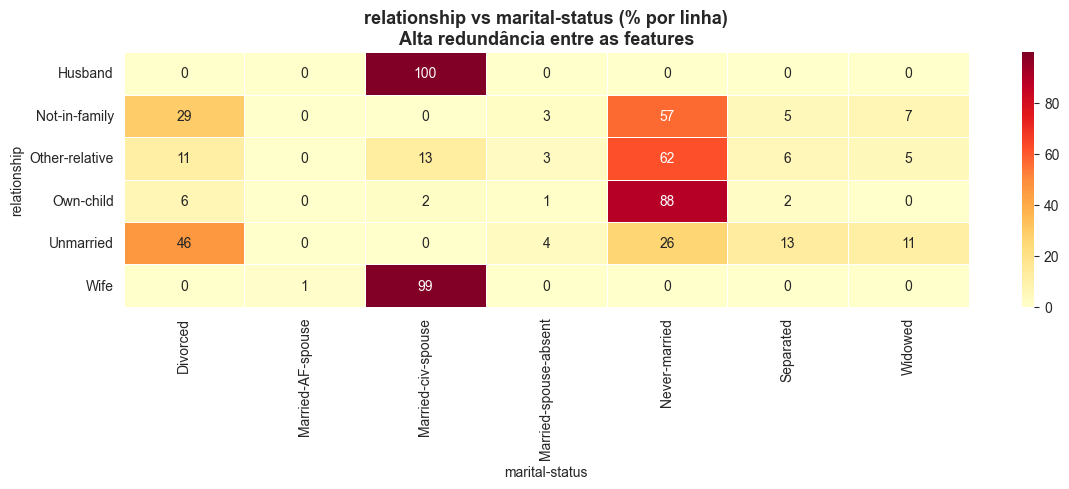


RESUMO DE QUALIDADE DOS DADOS:
  ┌────────────────────────────────────────────────────────────────┐
  │ PROBLEMA                       │ IMPACTO     │ AÇÃO SUGERIDA  │
  ├────────────────────────────────────────────────────────────────┤
  │ Missing values (7.4%)          │ Moderado    │ Imputação/moda │
  │ Desbalanceamento 3:1           │ Alto        │ SMOTE/weights  │
  │ Viés sexo (M: 30% vs F: 11%)  │ Alto        │ Monitorar bias │
  │ Viés raça (White: 85%)         │ Alto        │ Monitorar bias │
  │ Redundância education          │ Baixo       │ Remover 1 feat │
  │ Redundância relationship       │ Baixo       │ Remover 1 feat │
  │ capital-gain top-coded (99999) │ Moderado    │ Tratar/cap     │
  │ Viés geográfico (90% EUA)      │ Moderado    │ Documentar     │
  │ 24 duplicatas                  │ Muito baixo │ Remover        │
  │ Categorias raras               │ Baixo       │ Agrupar        │
  └────────────────────────────────────────────────────────────────┘


In [53]:
# --- 4.3.4 Inconsistências e registros problemáticos ---
print("4.3.4 INCONSISTÊNCIAS E REGISTROS PROBLEMÁTICOS\n")

# 1. Registros duplicados
duplicatas = df.duplicated().sum()
print(f"1. Registros duplicados: {duplicatas:,} ({duplicatas/len(df)*100:.2f}%)")

# 2. Categorias raras (< 0.1% do dataset)
print(f"\n2. Categorias raras (< 0.1% das instâncias):")
for col in categorical:
    freq = df[col].value_counts()
    rare = freq[freq < len(df) * 0.001]
    if len(rare) > 0:
        cats = ', '.join([f"'{c}' ({v})" for c, v in rare.items()])
        print(f"   {col}: {cats}")

# 3. Valor suspeito em capital-gain (99999)
cap_gain_max = (df['capital-gain'] == 99999).sum()
print(f"\n3. capital-gain = 99999 (possível valor censurado/truncado): {cap_gain_max:,} registros")
print(f"   Isso representa {cap_gain_max/len(df)*100:.2f}% do total.")
print(f"   Pode ser um limite superior de reporte no censo (top-coding).")

# 4. Viés geográfico: native-country
us_count = (df['native-country'] == 'United-States').sum()
print(f"\n4. Viés geográfico: {us_count:,} ({us_count/len(df)*100:.1f}%) são dos EUA.")
print(f"   Apenas {len(df) - us_count - (df['native-country'] == '?').sum():,} registros de outros países,")
print(f"   tornando difícil generalizar para populações não-americanas.")

# 5. relationship vs marital-status: sobreposição de informação
print(f"\n5. Sobreposição entre relationship e marital-status:")
rel_ms = pd.crosstab(df['relationship'], df['marital-status'])
print(f"   relationship tem {df['relationship'].nunique()} categorias, marital-status tem {df['marital-status'].nunique()}.")
# Cramer's V para medir associação
from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(rel_ms)
n = len(df)
k = min(rel_ms.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"   Cramér's V = {cramers_v:.4f} (associação muito forte, próximo de 1).")
print(f"   Essas features são altamente redundantes — considerar manter apenas uma na modelagem.")

# Visualização resumo: heatmap de relationship vs marital-status
plt.figure(figsize=(12, 5))
rel_ms_norm = pd.crosstab(df['relationship'], df['marital-status'], normalize='index') * 100
sns.heatmap(rel_ms_norm, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('relationship vs marital-status (% por linha)\nAlta redundância entre as features',
          fontsize=13, fontweight='bold')
plt.xlabel('marital-status')
plt.ylabel('relationship')
plt.tight_layout()
plt.show()

print("\nRESUMO DE QUALIDADE DOS DADOS:")
print("  ┌────────────────────────────────────────────────────────────────┐")
print("  │ PROBLEMA                       │ IMPACTO     │ AÇÃO SUGERIDA  │")
print("  ├────────────────────────────────────────────────────────────────┤")
print("  │ Missing values (7.4%)          │ Moderado    │ Imputação/moda │")
print("  │ Desbalanceamento 3:1           │ Alto        │ SMOTE/weights  │")
print("  │ Viés sexo (M: 30% vs F: 11%)  │ Alto        │ Monitorar bias │")
print("  │ Viés raça (White: 85%)         │ Alto        │ Monitorar bias │")
print("  │ Redundância education          │ Baixo       │ Remover 1 feat │")
print("  │ Redundância relationship       │ Baixo       │ Remover 1 feat │")
print("  │ capital-gain top-coded (99999) │ Moderado    │ Tratar/cap     │")
print("  │ Viés geográfico (90% EUA)      │ Moderado    │ Documentar     │")
print("  │ 24 duplicatas                  │ Muito baixo │ Remover        │")
print("  │ Categorias raras               │ Baixo       │ Agrupar        │")
print("  └────────────────────────────────────────────────────────────────┘")

# 5. Pré-processamento para Modelagem

Com base nos achados das seções anteriores, propomos e implementamos estratégias de pré-processamento para preparar o dataset para as fases de regressão e classificação. Cada decisão é **justificada pelos insights da EDA**.

Etapas cobertas:
1. **Tratamento de valores ausentes** — imputação pela moda (dados MAR, co-ocorrência workclass/occupation)
2. **Tratamento de outliers** — capping (winsorization) para preservar informação
3. **Balanceamento de classes** — SMOTE e class_weight como estratégias complementares
4. **Encoding de variáveis categóricas** — One-Hot para nominais, Ordinal para education
5. **Normalização / Padronização** — StandardScaler para features com outliers, MinMaxScaler como alternativa
6. **Pipeline completo** — sklearn Pipeline reutilizável para modelagem

## 5.1 - Tratamento de Valores Ausentes

**Achados da EDA (Seção 4.1):**
- Apenas 3 features têm valores ausentes: `workclass` (5.6%), `occupation` (5.7%) e `native-country` (1.8%).
- `workclass` e `occupation` faltam juntos em ~99% dos casos (coocorrência alta).
- A distribuição de `income` difere significativamente entre registros com e sem missing (teste χ², p < 0.05), indicando dados **MAR** (Missing At Random).

**Estratégia escolhida: Imputação pela moda (valor mais frequente)**
- **Por que não remover?** Perderíamos ~7.4% dos dados (2.399 linhas), e como os dados não são MCAR, a remoção introduziria viés, já que registros com missing tendem a ter menor renda.
- **Por que moda?** Para variáveis categóricas, a moda é a imputação mais natural e preserva a distribuição original. Alternativas como KNN-imputer são computacionalmente caras e pouco eficazes para categóricas com muitas classes.
- **Alternativa avançada:** Imputação por moda **condicionada ao target** (moda de workclass para `<=50K` e `>50K` separadamente), que preserva melhor a relação com o target.

5.1 TRATAMENTO DE VALORES AUSENTES

Valores ausentes ANTES da imputação:
  workclass           : 1,836 (5.64%)
  occupation          : 1,843 (5.66%)
  native-country      : 583 (1.79%)

--- Estratégia 1: Imputação pela Moda Global ---
  workclass            → moda = 'Private'
  occupation           → moda = 'Prof-specialty'
  native-country       → moda = 'United-States'

--- Estratégia 2 (recomendada): Imputação pela Moda Condicionada ao Target ---
  workclass            | income=<=50K → moda = 'Private' (1,645 registros)
  workclass            | income=>50K  → moda = 'Private' (191 registros)
  occupation           | income=<=50K → moda = 'Adm-clerical' (1,652 registros)
  occupation           | income=>50K  → moda = 'Exec-managerial' (191 registros)
  native-country       | income=<=50K → moda = 'United-States' (437 registros)
  native-country       | income=>50K  → moda = 'United-States' (146 registros)

Valores ausentes APÓS imputação:
  workclass           : 0
  occupation       

C:\Users\desac\AppData\Local\Temp\ipykernel_12728\3718828989.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


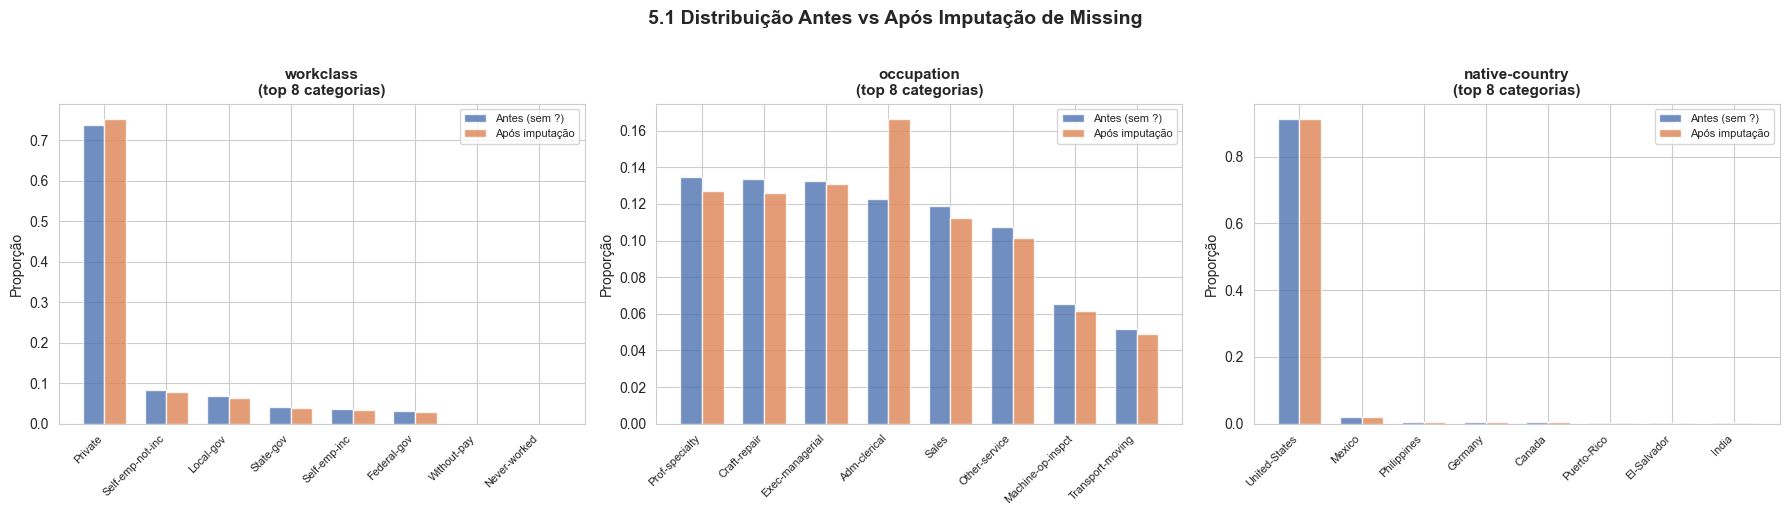


CONCLUSÃO:
  A imputação condicionada ao target preserva a distribuição original das categorias
  e mantém a relação entre as features imputadas e o target income.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

# Reconstruir listas de features
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
if 'income' in categorical:
    categorical.remove('income')

# --- 5.1 Tratamento de Valores Ausentes ---
print("5.1 TRATAMENTO DE VALORES AUSENTES\n")

# Criar cópia de trabalho para pré-processamento
df_proc = df.copy()

# Substituir '?' por NaN para facilitar tratamento
missing_cols = ['workclass', 'occupation', 'native-country']
df_proc[missing_cols] = df_proc[missing_cols].replace('?', np.nan)

print("Valores ausentes ANTES da imputação:")
for col in missing_cols:
    n_miss = df_proc[col].isna().sum()
    print(f"  {col:20s}: {n_miss:,} ({n_miss/len(df_proc)*100:.2f}%)")

# Estratégia 1: Imputação simples pela moda global
print("\n--- Estratégia 1: Imputação pela Moda Global ---")
for col in missing_cols:
    moda = df_proc[col].mode()[0]
    print(f"  {col:20s} → moda = '{moda}'")

# Estratégia 2 (recomendada): Imputação pela moda condicionada ao target
print("\n--- Estratégia 2 (recomendada): Imputação pela Moda Condicionada ao Target ---")
for col in missing_cols:
    for income_class in ['<=50K', '>50K']:
        moda_cond = df_proc.loc[df_proc['income'] == income_class, col].mode()[0]
        n_impute = ((df_proc[col].isna()) & (df_proc['income'] == income_class)).sum()
        print(f"  {col:20s} | income={income_class:5s} → moda = '{moda_cond}' ({n_impute:,} registros)")

# Aplicar imputação condicionada ao target
for col in missing_cols:
    for income_class in ['<=50K', '>50K']:
        moda_cond = df_proc.loc[df_proc['income'] == income_class, col].mode()[0]
        mask = (df_proc[col].isna()) & (df_proc['income'] == income_class)
        df_proc.loc[mask, col] = moda_cond

print("\nValores ausentes APÓS imputação:")
for col in missing_cols:
    n_miss = df_proc[col].isna().sum()
    print(f"  {col:20s}: {n_miss}")

# Verificação: comparar distribuição antes e depois
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(missing_cols):
    ax = axes[i]
    # Antes (original sem '?')
    orig_counts = df[df[col] != '?'][col].value_counts(normalize=True).head(8)
    proc_counts = df_proc[col].value_counts(normalize=True).head(8)
    
    x = np.arange(len(orig_counts))
    width = 0.35
    ax.bar(x - width/2, orig_counts.values, width, label='Antes (sem ?)', color='#4C72B0', alpha=0.8)
    ax.bar(x + width/2, proc_counts.reindex(orig_counts.index).values, width, label='Após imputação', color='#DD8452', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(orig_counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{col}\n(top 8 categorias)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proporção')
    ax.legend(fontsize=8)

plt.suptitle('5.1 Distribuição Antes vs Após Imputação de Missing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCONCLUSÃO:")
print("  A imputação condicionada ao target preserva a distribuição original das categorias")
print("  e mantém a relação entre as features imputadas e o target income.")

## 5.2 - Tratamento de Outliers

**Achados da EDA (Seção 2.5):**
- `capital-gain` e `capital-loss`: extremamente assimétricos (>90% são 0), com outliers extremos. O valor 99999 em `capital-gain` é provavelmente top-coded (censurado pelo censo).
- `fnlwgt`: cauda longa à direita (~3% de outliers pelo IQR). É um peso amostral e **não deve ser usado como feature preditora**.
- `hours-per-week`: ~28% de outliers pelo IQR, mas são valores reais de pessoas que trabalham muito pouco ou muito.
- `age` e `education-num`: poucos outliers, com valores legítimos.

**Estratégia escolhida: Capping (Winsorization) nos percentis 1% e 99%**
- **Por que não remover?** Outliers em `capital-gain`, `capital-loss` e `hours-per-week` representam informação real e relevante para prever renda. Removê-los perderia dados valiosos.
- **Por que não transformação log?** `capital-gain` e `capital-loss` têm muitos zeros, o que inviabiliza log diretamente. Uma alternativa seria `log(1 + x)`, mas capping é mais simples e interpretável.
- **Por que capping?** Limita valores extremos sem remover registros, preservando o tamanho do dataset e reduzindo o impacto de outliers na modelagem.

5.2 TRATAMENTO DE OUTLIERS — CAPPING (WINSORIZATION)

DECISÃO: Remover 'fnlwgt' — é um peso amostral do censo, sem valor preditivo.
  Antes: 15 colunas
  Após:  14 colunas

Feature              |         P1 |        P99 |   Afetados |  % Afet.
--------------------------------------------------------------------
age                  |         17 |         74 |        286 |    0.88%
capital-gain         |          0 |      15024 |        261 |    0.80%
capital-loss         |          0 |       1980 |        325 |    1.00%
hours-per-week       |          8 |         80 |        503 |    1.54%


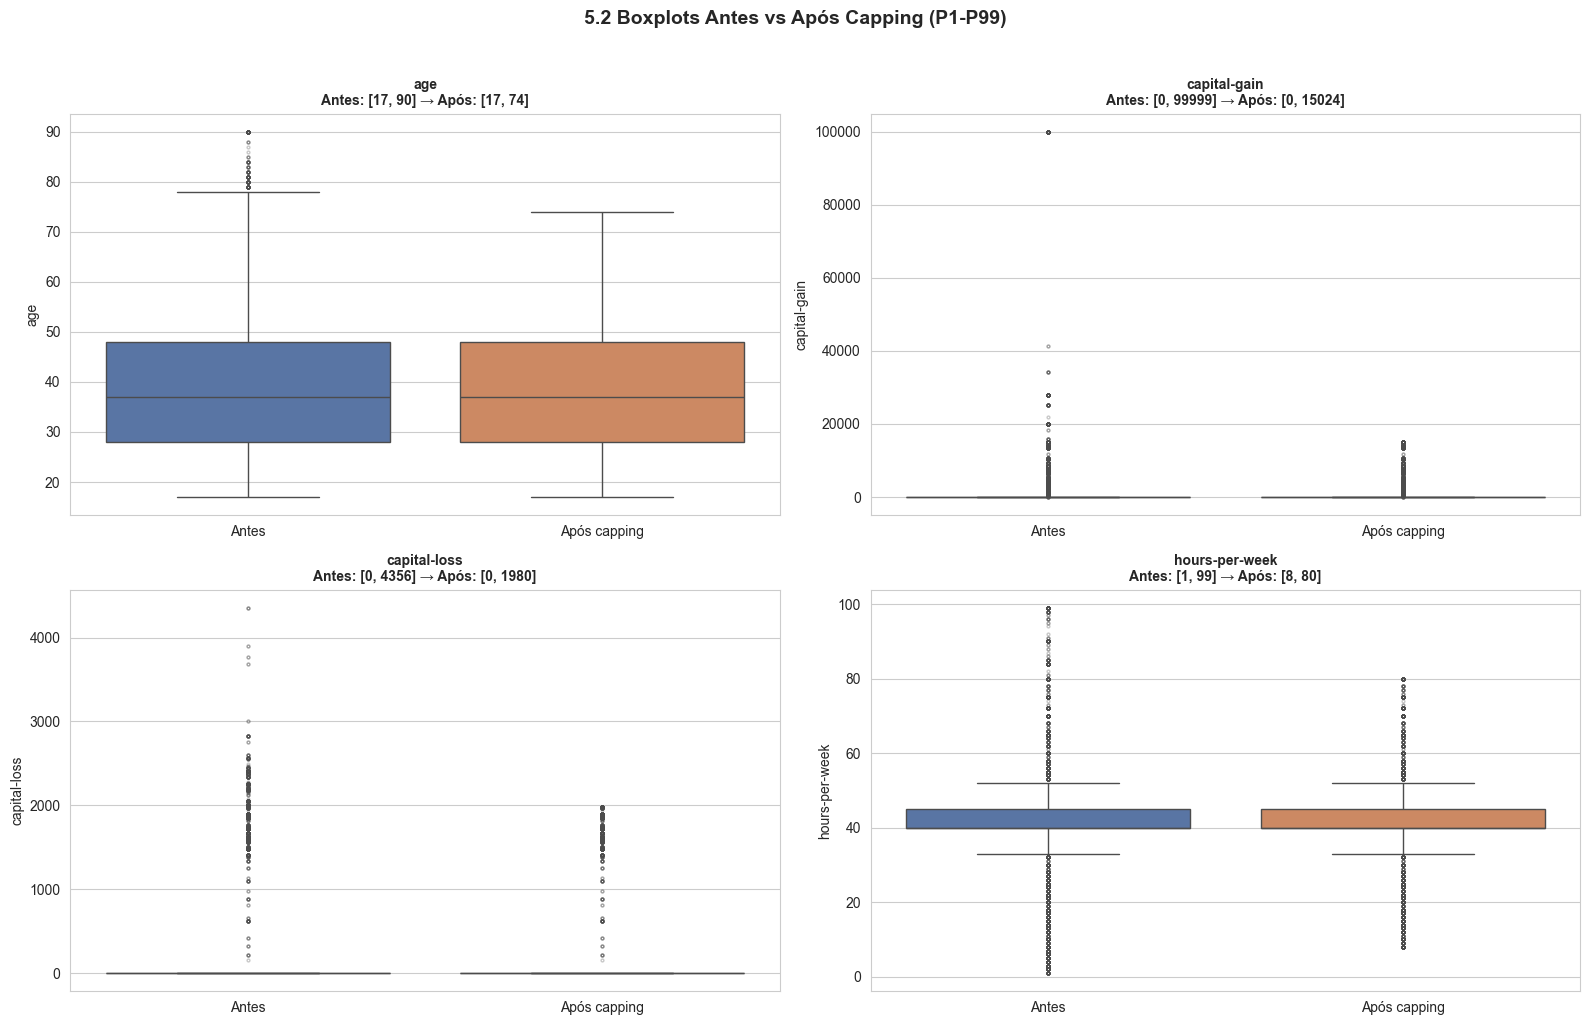


CONCLUSÃO:
  O capping reduziu os valores extremos sem remover registros.
  capital-gain e capital-loss foram os mais impactados, com valores
  extremos limitados ao percentil 99, tornando as distribuições mais
  tratáveis para algoritmos sensíveis a escala.


In [55]:
# --- 5.2 Tratamento de Outliers ---
print("5.2 TRATAMENTO DE OUTLIERS — CAPPING (WINSORIZATION)\n")

# Features numéricas a tratar (excluindo fnlwgt que será removido)
num_to_cap = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# Remover fnlwgt (peso amostral, não é feature preditora)
print("DECISÃO: Remover 'fnlwgt' — é um peso amostral do censo, sem valor preditivo.")
print(f"  Antes: {len(df_proc.columns)} colunas")
df_proc = df_proc.drop(columns=['fnlwgt'])
print(f"  Após:  {len(df_proc.columns)} colunas\n")

# Aplicar capping nos percentis 1% e 99%
print(f"{'Feature':20s} | {'P1':>10s} | {'P99':>10s} | {'Afetados':>10s} | {'% Afet.':>8s}")
print("-" * 68)

cap_info = {}
for col in num_to_cap:
    p1 = df_proc[col].quantile(0.01)
    p99 = df_proc[col].quantile(0.99)
    
    # Contar registros que serão afetados
    affected = ((df_proc[col] < p1) | (df_proc[col] > p99)).sum()
    pct = affected / len(df_proc) * 100
    
    cap_info[col] = {'p1': p1, 'p99': p99, 'before_min': df_proc[col].min(), 'before_max': df_proc[col].max()}
    
    # Aplicar capping
    df_proc[col] = df_proc[col].clip(lower=p1, upper=p99)
    
    cap_info[col]['after_min'] = df_proc[col].min()
    cap_info[col]['after_max'] = df_proc[col].max()
    
    print(f"{col:20s} | {p1:10.0f} | {p99:10.0f} | {affected:10,} | {pct:7.2f}%")

# Visualização: antes vs depois do capping
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_to_cap):
    ax = axes[i]
    info = cap_info[col]
    
    # Boxplot comparando antes e depois
    before_data = df[col] if col != 'fnlwgt' else None
    after_data = df_proc[col]
    
    box_data = pd.DataFrame({
        'Antes': df[col],
        'Após capping': after_data
    })
    sns.boxplot(data=box_data, ax=ax, palette=['#4C72B0', '#DD8452'],
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(f'{col}\nAntes: [{info["before_min"]:.0f}, {info["before_max"]:.0f}] → '
                 f'Após: [{info["after_min"]:.0f}, {info["after_max"]:.0f}]',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('5.2 Boxplots Antes vs Após Capping (P1-P99)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCONCLUSÃO:")
print("  O capping reduziu os valores extremos sem remover registros.")
print("  capital-gain e capital-loss foram os mais impactados, com valores")
print("  extremos limitados ao percentil 99, tornando as distribuições mais")
print("  tratáveis para algoritmos sensíveis a escala.")

## 5.3 - Estratégias para Desequilíbrio de Classes

**Achados da EDA (Seções 4.2 e 5 da inspeção inicial):**
- Razão de desbalanceamento: ~3.15:1 (`<=50K` : `>50K`).
- Um classificador ingênuo teria ~76% de acurácia prevendo sempre `<=50K`.
- A classe minoritária (`>50K`) é justamente a mais relevante para predição.

**Estratégias propostas:**

| Estratégia | Descrição | Quando usar |
|---|---|---|
| `class_weight='balanced'` | Ajusta pesos internamente no modelo | Primeira abordagem, simples e eficaz |
| **SMOTE** (Synthetic Minority Over-sampling) | Gera amostras sintéticas da classe minoritária | Quando `class_weight` não for suficiente |
| **Random Undersampling** | Remove instâncias da classe majoritária | Dataset grande, com risco de perda de informação |
| **Combinação (SMOTE + Tomek Links)** | Oversampling + limpeza de fronteira | Para melhorar separabilidade entre classes |

**Justificativa:** Aplicaremos SMOTE apenas no conjunto de **treino** (após o split), nunca no conjunto de teste, para evitar data leakage.

5.3 ESTRATÉGIAS PARA DESEQUILÍBRIO DE CLASSES

Distribuição ORIGINAL do treino:
  Classe 0 (<=50K): 19,775 (75.9%)
  Classe 1 (>50K):  6,273 (24.1%)

  [AVISO] imblearn não instalado. Instale com: pip install imbalanced-learn
  Demonstração de SMOTE pulada. A estratégia class_weight será usada no pipeline.

Pesos calculados para class_weight='balanced':
  Classe 0 (<=50K): peso = 0.6586
  Classe 1 (>50K):  peso = 2.0762
  → O modelo dará 3.15x mais importância aos erros na classe >50K.


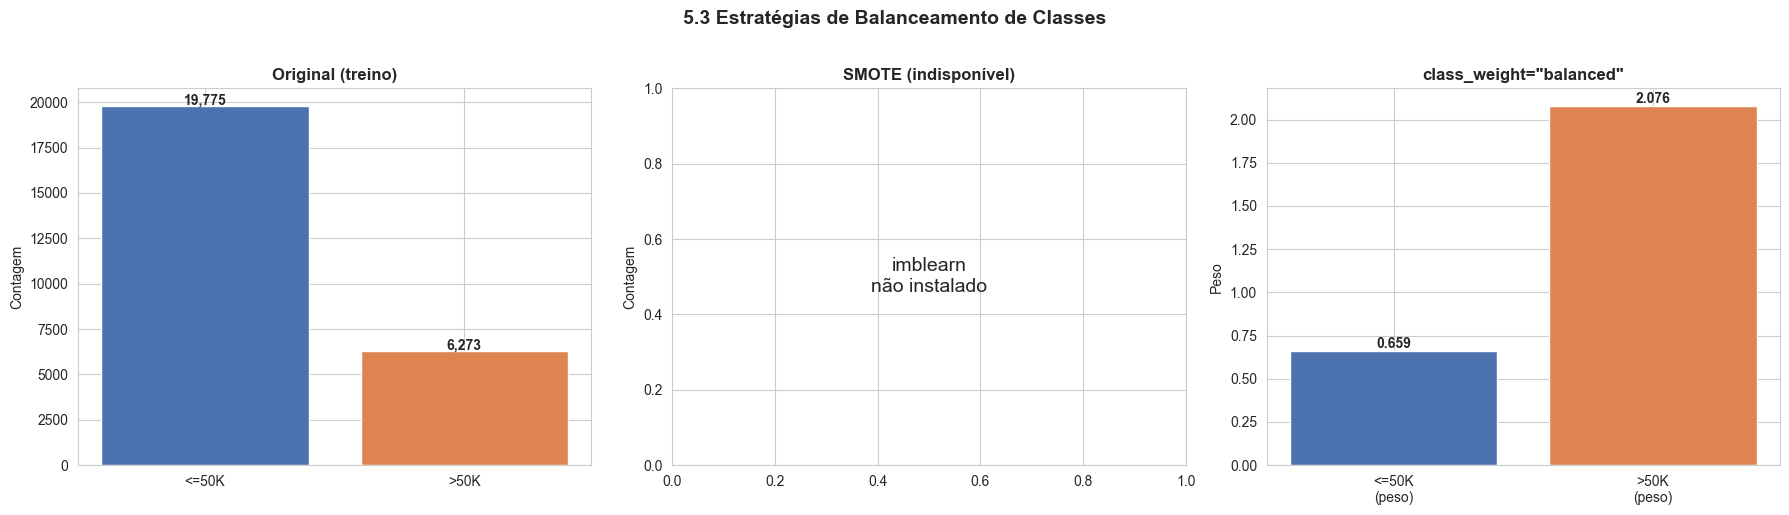


RECOMENDAÇÃO:
  1. Usar class_weight='balanced' como baseline (sem custo computacional adicional).
  2. Testar SMOTE no treino se o modelo tiver baixo recall na classe >50K.
  3. NUNCA aplicar balanceamento no conjunto de teste — ele deve refletir a distribuição real.


In [56]:
# --- 5.3 Demonstração de Balanceamento de Classes ---
print("5.3 ESTRATÉGIAS PARA DESEQUILÍBRIO DE CLASSES\n")

from sklearn.model_selection import train_test_split

# Separar features e target
X_demo = df_proc.drop(columns=['income'])
y_demo = (df_proc['income'] == '>50K').astype(int)  # Binarizar: 1 = >50K, 0 = <=50K

# Split treino/teste estratificado
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

print(f"Distribuição ORIGINAL do treino:")
print(f"  Classe 0 (<=50K): {(y_train_demo == 0).sum():,} ({(y_train_demo == 0).mean()*100:.1f}%)")
print(f"  Classe 1 (>50K):  {(y_train_demo == 1).sum():,} ({(y_train_demo == 1).mean()*100:.1f}%)")

# Demonstração de SMOTE (requer dados numéricos — usamos apenas as numéricas para demo)
num_cols_demo = [c for c in ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
                 if c in X_train_demo.columns]

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
    
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_train_demo[num_cols_demo], y_train_demo)
    
    print(f"\nDistribuição APÓS SMOTE (apenas features numéricas para demo):")
    print(f"  Classe 0 (<=50K): {(y_smote == 0).sum():,} ({(y_smote == 0).mean()*100:.1f}%)")
    print(f"  Classe 1 (>50K):  {(y_smote == 1).sum():,} ({(y_smote == 1).mean()*100:.1f}%)")
    
    smote_available = True
except ImportError:
    print("\n  [AVISO] imblearn não instalado. Instale com: pip install imbalanced-learn")
    print("  Demonstração de SMOTE pulada. A estratégia class_weight será usada no pipeline.")
    smote_available = False

# Demonstração de class_weight
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_demo.values)
print(f"\nPesos calculados para class_weight='balanced':")
print(f"  Classe 0 (<=50K): peso = {class_weights[0]:.4f}")
print(f"  Classe 1 (>50K):  peso = {class_weights[1]:.4f}")
print(f"  → O modelo dará {class_weights[1]/class_weights[0]:.2f}x mais importância aos erros na classe >50K.")

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
counts_orig = y_train_demo.value_counts().sort_index()
axes[0].bar(['<=50K', '>50K'], counts_orig.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
for j, v in enumerate(counts_orig.values):
    axes[0].text(j, v + 100, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Original (treino)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Contagem')

# SMOTE
if smote_available:
    counts_smote = pd.Series(y_smote).value_counts().sort_index()
    axes[1].bar(['<=50K', '>50K'], counts_smote.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
    for j, v in enumerate(counts_smote.values):
        axes[1].text(j, v + 100, f'{v:,}', ha='center', fontweight='bold')
    axes[1].set_title('Após SMOTE', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'imblearn\nnão instalado', ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('SMOTE (indisponível)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Contagem')

# Class weights
axes[2].bar(['<=50K\n(peso)', '>50K\n(peso)'], class_weights, color=['#4C72B0', '#DD8452'], edgecolor='white')
for j, v in enumerate(class_weights):
    axes[2].text(j, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[2].set_title('class_weight="balanced"', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Peso')

plt.suptitle('5.3 Estratégias de Balanceamento de Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nRECOMENDAÇÃO:")
print("  1. Usar class_weight='balanced' como baseline (sem custo computacional adicional).")
print("  2. Testar SMOTE no treino se o modelo tiver baixo recall na classe >50K.")
print("  3. NUNCA aplicar balanceamento no conjunto de teste — ele deve refletir a distribuição real.")

## 5.4 - Encoding de Variáveis Categóricas

**Achados da EDA (Seções 2.4 e 4.3):**
- `education` e `education-num` são redundantes, então `education` deve ser removida e `education-num` mantida.
- `relationship` e `marital-status` têm Cramér's V muito alto, então `relationship` deve ser removida e `marital-status` mantida.
- `sex` é binária, o que permite Label Encoding (0/1).
- Demais categóricas (`workclass`, `occupation`, `race`, `native-country`) são **nominais** e devem usar One-Hot Encoding.

**Estratégias escolhidas:**

| Feature | Tipo | Encoding | Justificativa |
|---|---|---|---|
| `education` | Redundante | **Remover** | Informação já em `education-num` |
| `relationship` | Redundante | **Remover** | Alta sobreposição com `marital-status` |
| `sex` | Binária | **Label Encoding** | Apenas 2 categorias |
| `workclass`, `occupation`, `race`, `marital-status` | Nominal | **One-Hot Encoding** | Sem ordem inerente |
| `native-country` | Nominal (42 categorias) | **Agrupar + One-Hot** | Muitas categorias raras, então faz sentido agrupar em regiões |

In [57]:
# --- 5.4 Encoding de Variáveis Categóricas ---
print("5.4 ENCODING DE VARIÁVEIS CATEGÓRICAS\n")

print(f"Colunas ANTES do encoding: {list(df_proc.columns)}\n")

# 1. Remover features redundantes
print("1. Remover features redundantes:")
print("   - 'education' (redundante com education-num)")
print("   - 'relationship' (redundante com marital-status)")
df_proc = df_proc.drop(columns=['education', 'relationship'])
print(f"   Colunas restantes: {len(df_proc.columns)}\n")

# 2. Agrupar native-country em regiões (reduzir 42 categorias → ~7 regiões)
print("2. Agrupar native-country em regiões geográficas:")
country_region = {
    'United-States': 'North-America', 'Canada': 'North-America',
    'Mexico': 'Latin-America', 'Cuba': 'Latin-America', 'Jamaica': 'Latin-America',
    'Puerto-Rico': 'Latin-America', 'Honduras': 'Latin-America', 'El-Salvador': 'Latin-America',
    'Guatemala': 'Latin-America', 'Nicaragua': 'Latin-America', 'Dominican-Republic': 'Latin-America',
    'Haiti': 'Latin-America', 'Trinadad&Tobago': 'Latin-America', 'Columbia': 'Latin-America',
    'Ecuador': 'Latin-America', 'Peru': 'Latin-America',
    'England': 'Europe', 'Germany': 'Europe', 'Italy': 'Europe', 'Poland': 'Europe',
    'Portugal': 'Europe', 'France': 'Europe', 'Greece': 'Europe', 'Ireland': 'Europe',
    'Hungary': 'Europe', 'Scotland': 'Europe', 'Yugoslavia': 'Europe',
    'Holand-Netherlands': 'Europe',
    'India': 'Asia', 'China': 'Asia', 'Japan': 'Asia', 'Taiwan': 'Asia',
    'Philippines': 'Asia', 'Vietnam': 'Asia', 'Laos': 'Asia', 'Cambodia': 'Asia',
    'Thailand': 'Asia', 'Hong': 'Asia', 'Iran': 'Asia',
    'South': 'Other', 'Outlying-US(Guam-USVI-etc)': 'Other'
}
df_proc['native-region'] = df_proc['native-country'].map(country_region).fillna('Other')
df_proc = df_proc.drop(columns=['native-country'])

region_counts = df_proc['native-region'].value_counts()
for reg, cnt in region_counts.items():
    print(f"   {reg:20s}: {cnt:6,} ({cnt/len(df_proc)*100:.2f}%)")

# 3. Label encoding para sex
print("\n3. Label Encoding para 'sex':")
df_proc['sex'] = (df_proc['sex'] == 'Male').astype(int)
print(f"   Male → 1, Female → 0")

# 4. Binarizar target
print("\n4. Binarizar target 'income':")
df_proc['income'] = (df_proc['income'] == '>50K').astype(int)
print(f"   >50K → 1, <=50K → 0")

# 5. One-Hot Encoding para features nominais
ohe_cols = ['workclass', 'occupation', 'race', 'marital-status', 'native-region']
print(f"\n5. One-Hot Encoding para: {ohe_cols}")
print(f"   Colunas antes do OHE: {len(df_proc.columns)}")

df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True, dtype=int)

print(f"   Colunas após OHE:     {len(df_proc.columns)}")

# Resumo final
print(f"\n{'='*60}")
print(f"RESUMO DO ENCODING:")
print(f"{'='*60}")
num_features = df_proc.drop(columns=['income']).select_dtypes(include=['int64', 'float64', 'int32', 'uint8']).columns
print(f"  Total de features após encoding: {len(num_features)}")
print(f"  Todas numéricas: {df_proc.drop(columns=['income']).select_dtypes(include=['object']).shape[1] == 0}")
print(f"\n  Features finais:")
for i, col in enumerate(df_proc.columns, 1):
    dtype = df_proc[col].dtype
    nunique = df_proc[col].nunique()
    print(f"    {i:2d}. {col:40s} (dtype: {dtype}, unique: {nunique})")

5.4 ENCODING DE VARIÁVEIS CATEGÓRICAS

Colunas ANTES do encoding: ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

1. Remover features redundantes:
   - 'education' (redundante com education-num)
   - 'relationship' (redundante com marital-status)
   Colunas restantes: 12

2. Agrupar native-country em regiões geográficas:
   North-America       : 29,874 (91.75%)
   Latin-America       :  1,401 (4.30%)
   Asia                :    671 (2.06%)
   Europe              :    521 (1.60%)
   Other               :     94 (0.29%)

3. Label Encoding para 'sex':
   Male → 1, Female → 0

4. Binarizar target 'income':
   >50K → 1, <=50K → 0

5. One-Hot Encoding para: ['workclass', 'occupation', 'race', 'marital-status', 'native-region']
   Colunas antes do OHE: 12
   Colunas após OHE:     41

RESUMO DO ENCODING:
  Total de features após encoding: 40
  Todas n

## 5.5 - Normalização e Padronização de Variáveis Numéricas

**Achados da EDA (Seção 2.1):**
- As features numéricas têm escalas muito diferentes: `age` (17-90), `capital-gain` (0-99999) e `hours-per-week` (1-99).
- `capital-gain` e `capital-loss` são extremamente assimétricos (skew > 4), com a maioria dos valores em 0.
- Algoritmos sensíveis a escala (regressão logística, SVM, KNN e redes neurais) requerem normalização.

**Estratégias propostas:**

| Método | Fórmula | Quando usar |
|---|---|---|
| **StandardScaler** | `(x - μ) / σ` | Dados com outliers moderados e algoritmos que assumem distribuição aproximadamente normal |
| **MinMaxScaler** | `(x - min) / (max - min)` | Quando se deseja valores em [0, 1], sem outliers extremos |
| **RobustScaler** | `(x - mediana) / IQR` | Dados com muitos outliers, usando mediana e IQR em vez de média e desvio padrão |

**Escolha:** `StandardScaler` como padrão, pois após o capping (5.2) os outliers extremos já foram tratados, e a maioria dos algoritmos de ML funciona bem com dados padronizados. Para `capital-gain` e `capital-loss`, o `RobustScaler` permanece como alternativa.

5.5 NORMALIZAÇÃO E PADRONIZAÇÃO DE VARIÁVEIS NUMÉRICAS

Estatísticas ANTES da padronização:
            age  education-num  capital-gain  capital-loss  hours-per-week
count  32561.00       32561.00      32561.00      32561.00        32561.00
mean      38.53          10.08        633.81         83.80           40.39
std       13.48           2.57       2521.10        382.96           11.94
min       17.00           1.00          0.00          0.00            8.00
25%       28.00           9.00          0.00          0.00           40.00
50%       37.00          10.00          0.00          0.00           40.00
75%       48.00          12.00          0.00          0.00           45.00
max       74.00          16.00      15024.00       1980.00           80.00


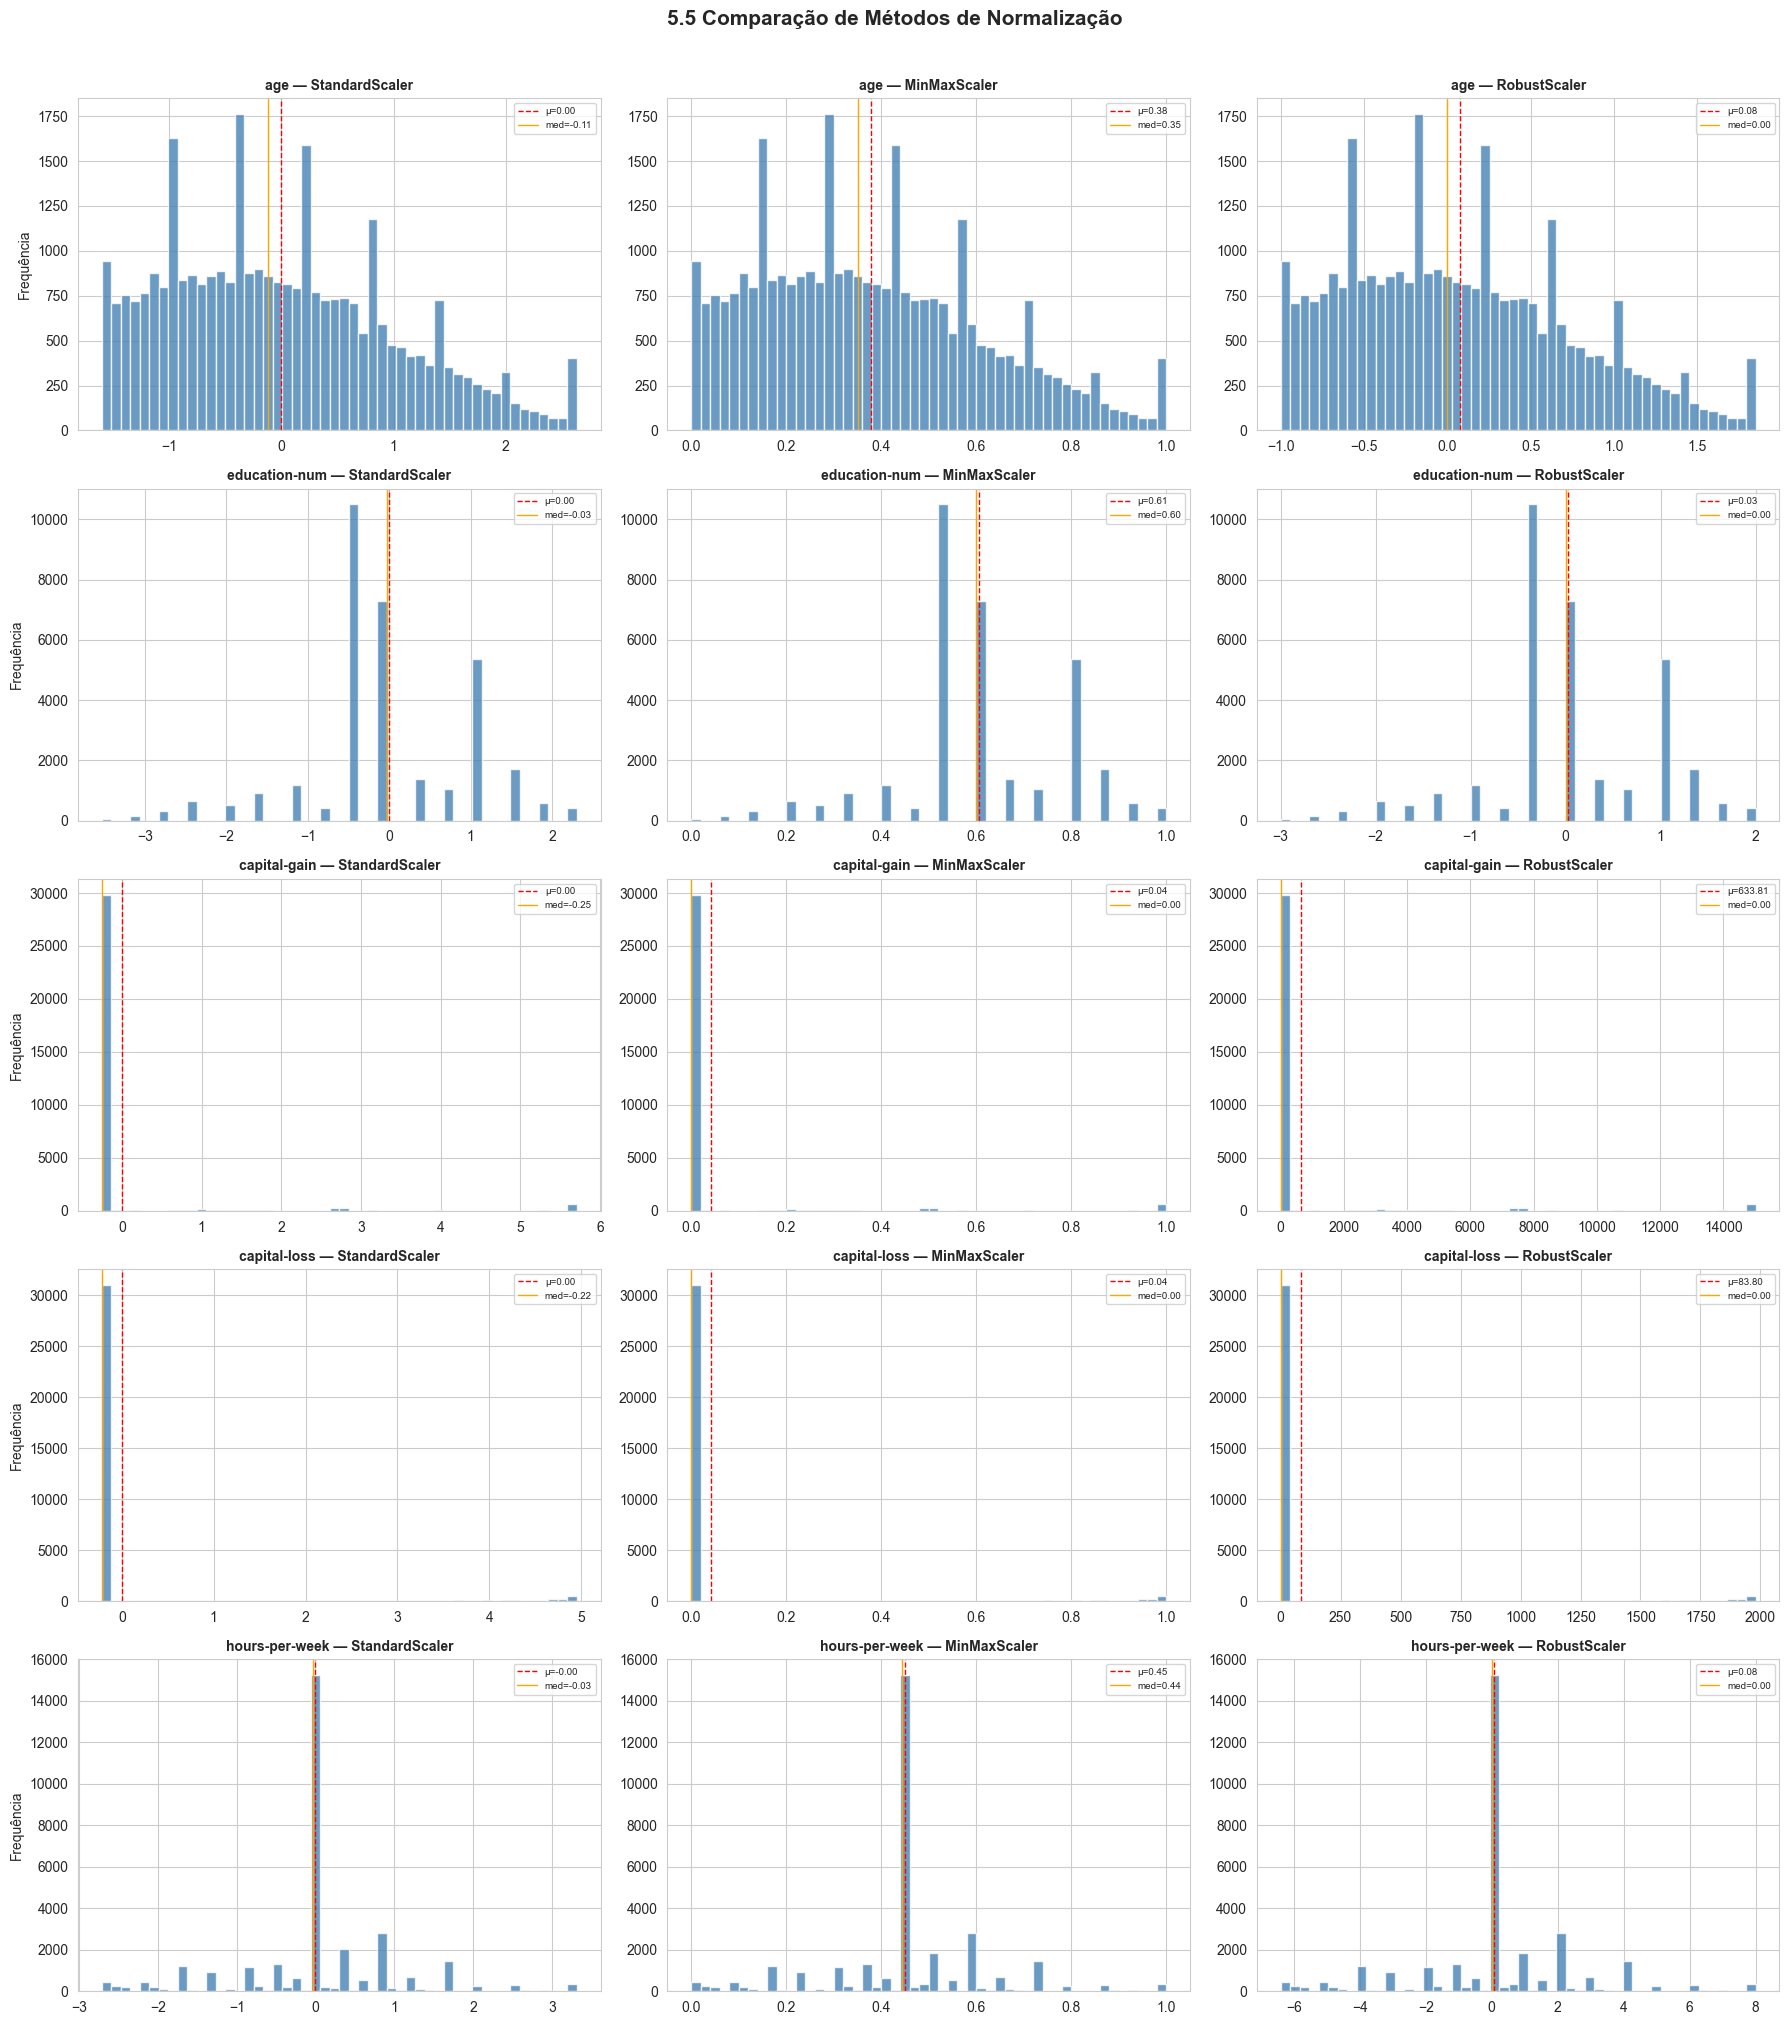


Aplicando StandardScaler nas features contínuas:

Estatísticas APÓS padronização (StandardScaler):
              age  education-num  capital-gain  capital-loss  hours-per-week
count  32561.0000     32561.0000    32561.0000    32561.0000      32561.0000
mean       0.0000         0.0000        0.0000        0.0000         -0.0000
std        1.0000         1.0000        1.0000        1.0000          1.0000
min       -1.5970        -3.5297       -0.2514       -0.2188         -2.7130
25%       -0.7810        -0.4201       -0.2514       -0.2188         -0.0327
50%       -0.1134        -0.0314       -0.2514       -0.2188         -0.0327
75%        0.7026         0.7460       -0.2514       -0.2188          0.3861
max        2.6313         2.3008        5.7080        4.9516          3.3177

CONCLUSÃO:
  - StandardScaler aplicado: todas as features contínuas agora têm média ≈ 0 e std ≈ 1.
  - Features binárias (sex, OHE) NÃO foram escaladas — já estão em {0, 1}.
  - Na fase de modelagem, o scal

In [58]:
# --- 5.5 Normalização e Padronização ---
print("5.5 NORMALIZAÇÃO E PADRONIZAÇÃO DE VARIÁVEIS NUMÉRICAS\n")

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Features numéricas contínuas (não binárias/OHE)
num_continuous = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print("Estatísticas ANTES da padronização:")
print(df_proc[num_continuous].describe().round(2).to_string())

# Demonstrar os 3 métodos lado a lado
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(len(num_continuous), 3, figsize=(18, 4 * len(num_continuous)))

for j, (name, scaler) in enumerate(scalers.items()):
    scaled = pd.DataFrame(
        scaler.fit_transform(df_proc[num_continuous]),
        columns=num_continuous
    )
    for i, col in enumerate(num_continuous):
        ax = axes[i][j]
        ax.hist(scaled[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(scaled[col].mean(), color='red', linestyle='--', linewidth=1, label=f'μ={scaled[col].mean():.2f}')
        ax.axvline(scaled[col].median(), color='orange', linestyle='-', linewidth=1, label=f'med={scaled[col].median():.2f}')
        ax.set_title(f'{col} — {name}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)
        if j == 0:
            ax.set_ylabel('Frequência')

plt.suptitle('5.5 Comparação de Métodos de Normalização', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Aplicar StandardScaler nas contínuas
print("\nAplicando StandardScaler nas features contínuas:")
scaler_final = StandardScaler()
df_proc[num_continuous] = scaler_final.fit_transform(df_proc[num_continuous])

print("\nEstatísticas APÓS padronização (StandardScaler):")
print(df_proc[num_continuous].describe().round(4).to_string())

print("\nCONCLUSÃO:")
print("  - StandardScaler aplicado: todas as features contínuas agora têm média ≈ 0 e std ≈ 1.")
print("  - Features binárias (sex, OHE) NÃO foram escaladas — já estão em {0, 1}.")
print("  - Na fase de modelagem, o scaler deve ser fitado APENAS no treino e aplicado no teste")
print("    (via pipeline) para evitar data leakage.")

## 5.6 - Pipeline Completo de Pré-processamento

Construímos um pipeline reutilizável com `sklearn` que encapsula todas as etapas de pré-processamento definidas acima, garantindo que:
- O pipeline seja **fitado apenas nos dados de treino** (evitando data leakage).
- As transformações sejam **aplicáveis a novos dados** de forma consistente.
- Seja compatível com as fases de **regressão** e **classificação** das APS2 e APS3.

O pipeline parte dos **dados brutos** (DataFrame original) e aplica:
1. Remoção de features redundantes (`fnlwgt`, `education`, `relationship`)
2. Substituição de `?` por `NaN`
3. Imputação pela moda (`SimpleImputer` com `strategy='most_frequent'`)
4. Agrupamento de `native-country` em regiões
5. One-Hot Encoding para categóricas nominais
6. StandardScaler para features contínuas

In [59]:
# --- 5.6 Pipeline Completo de Pré-processamento ---
print("5.6 PIPELINE COMPLETO DE PRÉ-PROCESSAMENTO\n")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# --- Função auxiliar para pré-processar o DataFrame bruto ---
def preprocess_raw(df_raw):
    """
    Prepara o DataFrame bruto para o pipeline do sklearn:
    - Remove features redundantes (fnlwgt, education, relationship)
    - Substitui '?' por NaN
    - Agrupa native-country em regiões
    - Binariza sex
    """
    df_clean = df_raw.copy()
    
    # Remover redundantes
    df_clean = df_clean.drop(columns=['fnlwgt', 'education', 'relationship'])
    
    # Substituir '?' por NaN
    df_clean = df_clean.replace('?', np.nan)
    
    # Agrupar native-country em regiões
    country_region = {
        'United-States': 'North-America', 'Canada': 'North-America',
        'Mexico': 'Latin-America', 'Cuba': 'Latin-America', 'Jamaica': 'Latin-America',
        'Puerto-Rico': 'Latin-America', 'Honduras': 'Latin-America', 'El-Salvador': 'Latin-America',
        'Guatemala': 'Latin-America', 'Nicaragua': 'Latin-America', 'Dominican-Republic': 'Latin-America',
        'Haiti': 'Latin-America', 'Trinadad&Tobago': 'Latin-America', 'Columbia': 'Latin-America',
        'Ecuador': 'Latin-America', 'Peru': 'Latin-America',
        'England': 'Europe', 'Germany': 'Europe', 'Italy': 'Europe', 'Poland': 'Europe',
        'Portugal': 'Europe', 'France': 'Europe', 'Greece': 'Europe', 'Ireland': 'Europe',
        'Hungary': 'Europe', 'Scotland': 'Europe', 'Yugoslavia': 'Europe',
        'Holand-Netherlands': 'Europe',
        'India': 'Asia', 'China': 'Asia', 'Japan': 'Asia', 'Taiwan': 'Asia',
        'Philippines': 'Asia', 'Vietnam': 'Asia', 'Laos': 'Asia', 'Cambodia': 'Asia',
        'Thailand': 'Asia', 'Hong': 'Asia', 'Iran': 'Asia',
        'South': 'Other', 'Outlying-US(Guam-USVI-etc)': 'Other'
    }
    df_clean['native-region'] = df_clean['native-country'].map(country_region).fillna('Other')
    df_clean = df_clean.drop(columns=['native-country'])
    
    # Binarizar sex
    df_clean['sex'] = (df_clean['sex'] == 'Male').astype(int)
    
    return df_clean

# --- Preparar dados ---
df_clean = preprocess_raw(df)

# Separar X e y
X = df_clean.drop(columns=['income'])
y = (df_clean['income'] == '>50K').astype(int)

# Identificar tipos de colunas
num_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_features = ['workclass', 'occupation', 'race', 'marital-status', 'native-region']
pass_features = ['sex']  # Já binária

print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")
print(f"Features passthrough ({len(pass_features)}): {pass_features}")

# --- Construir Pipeline ---

# Sub-pipeline para features numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Mediana para numéricas (robusta a outliers)
    ('scaler', StandardScaler())
])

# Sub-pipeline para features categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Moda para categóricas
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer combina os sub-pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('pass', 'passthrough', pass_features)
    ],
    remainder='drop'
)

# --- Split treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSplit treino/teste:")
print(f"  Treino: {X_train.shape[0]:,} instâncias")
print(f"  Teste:  {X_test.shape[0]:,} instâncias")

# --- Fit no treino, transform em ambos ---
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Recuperar nomes das features transformadas
ohe_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_feature_names + pass_features

print(f"\n{'='*60}")
print(f"PIPELINE APLICADO COM SUCESSO!")
print(f"{'='*60}")
print(f"  Shape treino transformado: {X_train_transformed.shape}")
print(f"  Shape teste transformado:  {X_test_transformed.shape}")
print(f"  Total de features finais:  {len(all_feature_names)}")

print(f"\n  Distribuição do target no treino:")
print(f"    Classe 0 (<=50K): {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"    Classe 1 (>50K):  {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\n  Distribuição do target no teste:")
print(f"    Classe 0 (<=50K): {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"    Classe 1 (>50K):  {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")

5.6 PIPELINE COMPLETO DE PRÉ-PROCESSAMENTO

Features numéricas (5): ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Features categóricas (5): ['workclass', 'occupation', 'race', 'marital-status', 'native-region']
Features passthrough (1): ['sex']

Split treino/teste:
  Treino: 26,048 instâncias
  Teste:  6,513 instâncias

PIPELINE APLICADO COM SUCESSO!
  Shape treino transformado: (26048, 40)
  Shape teste transformado:  (6513, 40)
  Total de features finais:  40

  Distribuição do target no treino:
    Classe 0 (<=50K): 19,775 (75.9%)
    Classe 1 (>50K):  6,273 (24.1%)

  Distribuição do target no teste:
    Classe 0 (<=50K): 4,945 (75.9%)
    Classe 1 (>50K):  1,568 (24.1%)


5.6.2 VERIFICAÇÃO FINAL DO PIPELINE

Estatísticas das features numéricas (treino transformado):
              age  education-num  capital-gain  capital-loss  hours-per-week
count  26048.0000     26048.0000    26048.0000    26048.0000      26048.0000
mean      -0.0000         0.0000       -0.0000       -0.0000         -0.0000
std        1.0000         1.0000        1.0000        1.0000          1.0000
min       -1.5827        -3.5150       -0.1453       -0.2174         -3.1795
25%       -0.7763        -0.4180       -0.1453       -0.2174         -0.0387
50%       -0.1165        -0.0308       -0.1453       -0.2174         -0.0387
75%        0.6899         0.7434       -0.1453       -0.2174          0.3639
max        3.7689         2.2919       13.5550       10.5388          4.7127

Verificação: média ≈ 0 e std ≈ 1 para features contínuas? SIM


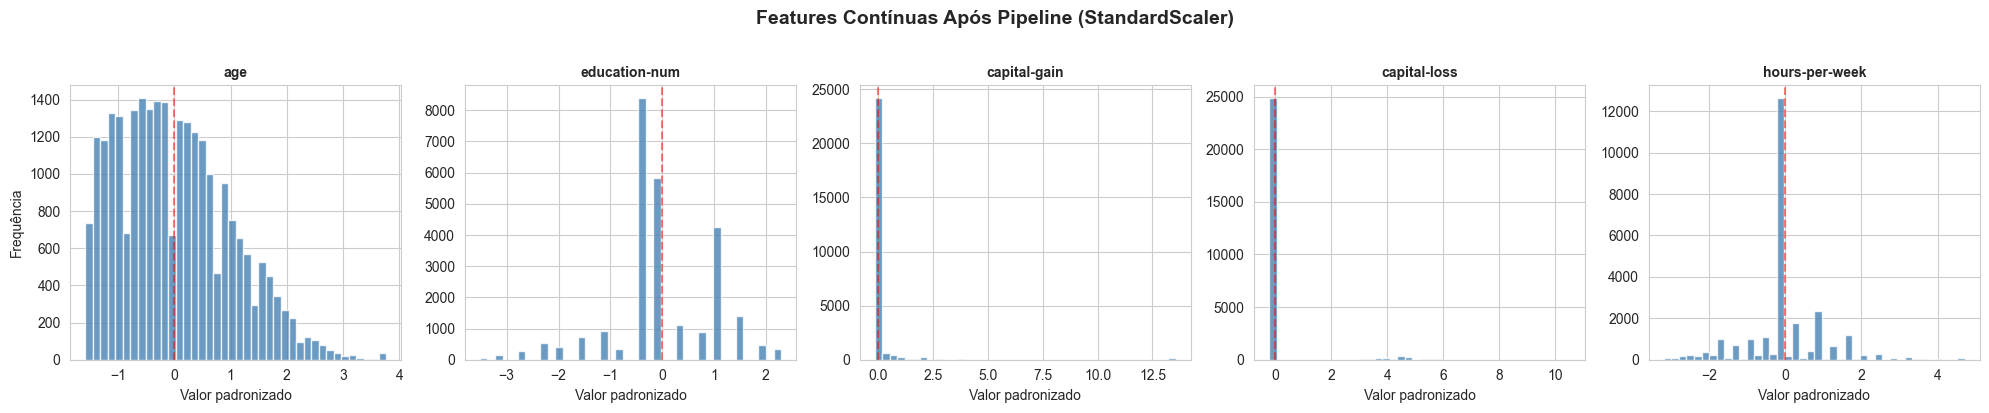


  DIAGRAMA DO PIPELINE DE PRÉ-PROCESSAMENTO

  DataFrame Bruto (32,561 × 15)
       │
       ▼
  ┌─────────────────────────────────┐
  │  Remover: fnlwgt, education,    │
  │           relationship          │
  │  Substituir '?' → NaN           │
  │  Agrupar native-country → região│
  │  Binarizar sex (Male=1)         │
  └─────────────┬───────────────────┘
                │
       ┌────────┼────────┐
       ▼        ▼        ▼
  ┌─────────┐ ┌──────┐ ┌──────────┐
  │NUMÉRICAS│ │CATEG.│ │PASSTHRU  │
  │ 5 feat. │ │5 feat│ │ sex (1)  │
  ├─────────┤ ├──────┤ └──────────┘
  │Imputer  │ │Imputer│
  │(median) │ │(moda) │
  ├─────────┤ ├──────┤
  │Standard │ │OneHot │
  │Scaler   │ │Encod. │
  └────┬────┘ └──┬───┘
       │         │
       └────┬────┘
            ▼
  ┌─────────────────────────────────┐
  │  X_train: (26,048 × N features)│
  │  X_test:  ( 6,513 × N features)│
  │  Pronto para modelagem!        │
  └─────────────────────────────────┘

  → Pipeline reutilizável para APS2 (Reg

In [60]:
# --- 5.6.2 Visualização do pipeline e verificação final ---
print("5.6.2 VERIFICAÇÃO FINAL DO PIPELINE\n")

# Criar DataFrame com os dados transformados para inspeção
df_train_final = pd.DataFrame(X_train_transformed, columns=all_feature_names)

print("Estatísticas das features numéricas (treino transformado):")
print(df_train_final[num_features].describe().round(4).to_string())

print(f"\nVerificação: média ≈ 0 e std ≈ 1 para features contínuas? ", end="")
means_ok = (df_train_final[num_features].mean().abs() < 0.01).all()
stds_ok = ((df_train_final[num_features].std() - 1).abs() < 0.01).all()
print(f"{'SIM' if means_ok and stds_ok else 'NÃO'}")

# Visualização: distribuição das features contínuas após pipeline
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_features):
    ax = axes[i]
    ax.hist(df_train_final[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor padronizado')
    if i == 0:
        ax.set_ylabel('Frequência')

plt.suptitle('Features Contínuas Após Pipeline (StandardScaler)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Diagrama resumo do pipeline
print("\n" + "="*70)
print("  DIAGRAMA DO PIPELINE DE PRÉ-PROCESSAMENTO")
print("="*70)
print("""
  DataFrame Bruto (32,561 × 15)
       │
       ▼
  ┌─────────────────────────────────┐
  │  Remover: fnlwgt, education,    │
  │           relationship          │
  │  Substituir '?' → NaN           │
  │  Agrupar native-country → região│
  │  Binarizar sex (Male=1)         │
  └─────────────┬───────────────────┘
                │
       ┌────────┼────────┐
       ▼        ▼        ▼
  ┌─────────┐ ┌──────┐ ┌──────────┐
  │NUMÉRICAS│ │CATEG.│ │PASSTHRU  │
  │ 5 feat. │ │5 feat│ │ sex (1)  │
  ├─────────┤ ├──────┤ └──────────┘
  │Imputer  │ │Imputer│
  │(median) │ │(moda) │
  ├─────────┤ ├──────┤
  │Standard │ │OneHot │
  │Scaler   │ │Encod. │
  └────┬────┘ └──┬───┘
       │         │
       └────┬────┘
            ▼
  ┌─────────────────────────────────┐
  │  X_train: (26,048 × N features)│
  │  X_test:  ( 6,513 × N features)│
  │  Pronto para modelagem!        │
  └─────────────────────────────────┘
""")

print(f"  → Pipeline reutilizável para APS2 (Regressão) e APS3 (Classificação).")
print(f"  → Objeto 'preprocessor' pode ser salvo com joblib e reutilizado.")
print(f"  → Para usar com modelo: Pipeline([('preprocessor', preprocessor), ('model', clf)])")

# 6. Redução de Dimensionalidade

- Propor e aplicar técnicas de redução de dimensionalidade, como PCA, t-SNE ou UMAP, para visualizar a estrutura dos dados e identificar possíveis agrupamentos ou padrões.
- Analisar os resultados da redução de dimensionalidade para obter insights sobre a separabilidade das classes e a importância das features.

## 6.1 - Aplicando PCA para visualizar a estrutura dos dados e identificar possíveis agrupamentos ou padrões.


Variancia explicada pelo PCA 2D:
  PC1: 19.09%
  PC2: 14.31%
  Total (PC1 + PC2): 33.40%


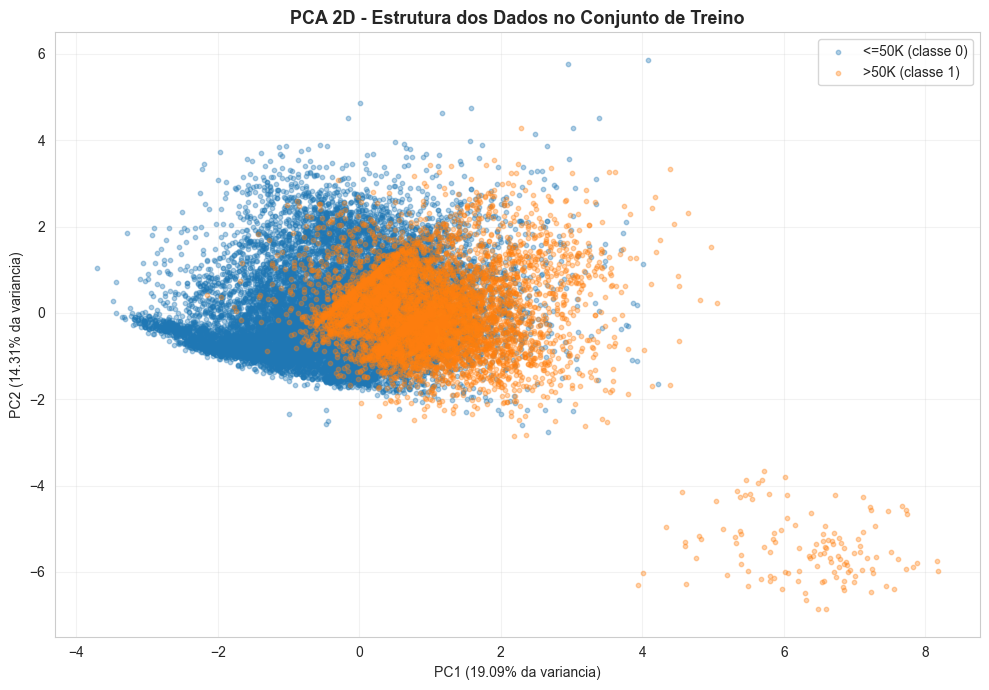

In [61]:
from sklearn.decomposition import PCA

# Usar os dados de treino ja pre-processados no item 5
X_pca_base = np.asarray(X_train_transformed)
y_pca_base = np.asarray(y_train)

# PCA para visualizacao em 2D
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_pca_base)

var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2

print(f"\nVariancia explicada pelo PCA 2D:")
print(f"  PC1: {var_pc1:.2f}%")
print(f"  PC2: {var_pc2:.2f}%")
print(f"  Total (PC1 + PC2): {var_total:.2f}%")

# Visualizacao da estrutura dos dados em 2 componentes principais
plt.figure(figsize=(10, 7))
plt.scatter(
    X_train_pca_2d[y_pca_base == 0, 0],
    X_train_pca_2d[y_pca_base == 0, 1],
    s=10,
    alpha=0.35,
    label="<=50K (classe 0)"
)
plt.scatter(
    X_train_pca_2d[y_pca_base == 1, 0],
    X_train_pca_2d[y_pca_base == 1, 1],
    s=10,
    alpha=0.35,
    label=">50K (classe 1)"
)
plt.title("PCA 2D - Estrutura dos Dados no Conjunto de Treino", fontsize=13, fontweight="bold")
plt.xlabel(f"PC1 ({var_pc1:.2f}% da variancia)")
plt.ylabel(f"PC2 ({var_pc2:.2f}% da variancia)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6.2 - Analisando os resultados da redução de dimensionalidade para obter insights sobre a separabilidade das classes e a importância das features.


Resumo da variancia acumulada:
  Componentes para 90% da variancia: 14
  Componentes para 95% da variancia: 19

Separabilidade das classes no PCA 2D:
  Silhouette score (labels reais): 0.1687
  Distancia entre centroides: 1.4046

Top 8 features mais influentes em PC1 (|loading|):
hours-per-week                       0.496411
education-num                        0.475537
age                                  0.466427
capital-gain                         0.368837
capital-loss                         0.252658
marital-status_Never-married         0.189134
marital-status_Married-civ-spouse    0.186391
workclass_Private                    0.104688

Top 8 features mais influentes em PC2 (|loading|):
age                                  0.663911
education-num                        0.491382
capital-gain                         0.382129
capital-loss                         0.296539
marital-status_Never-married         0.197359
hours-per-week                       0.142753
marital-status_Married

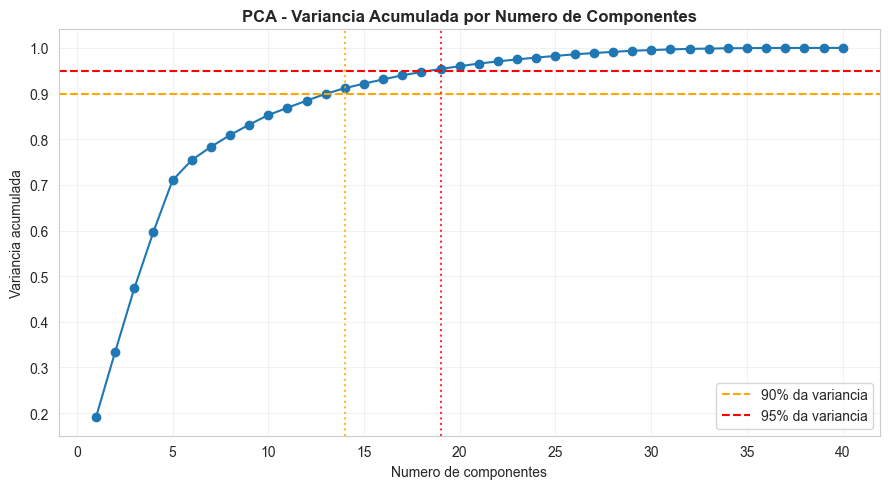


Insights gerais:
  - O PCA 2D permite visualizar padroes globais e sobreposicao entre as classes.
  - Se muitos componentes forem necessarios para 90%-95%, ha alta complexidade estrutural nos dados.
  - As features com maior |loading| em PC1/PC2 sao as que mais contribuem para a projecao.


In [63]:
from sklearn.metrics import silhouette_score

# PCA completo para avaliar quanta dimensionalidade preserva a variancia
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_base)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_comp_90 = int(np.argmax(cumulative >= 0.90) + 1)
n_comp_95 = int(np.argmax(cumulative >= 0.95) + 1)

print("\nResumo da variancia acumulada:")
print(f"  Componentes para 90% da variancia: {n_comp_90}")
print(f"  Componentes para 95% da variancia: {n_comp_95}")

# Medida simples de separabilidade no espaco 2D do PCA
sil = silhouette_score(X_train_pca_2d, y_pca_base)
centroid_0 = X_train_pca_2d[y_pca_base == 0].mean(axis=0)
centroid_1 = X_train_pca_2d[y_pca_base == 1].mean(axis=0)
centroid_dist = np.linalg.norm(centroid_0 - centroid_1)

print("\nSeparabilidade das classes no PCA 2D:")
print(f"  Silhouette score (labels reais): {sil:.4f}")
print(f"  Distancia entre centroides: {centroid_dist:.4f}")

# Importancia das features via loadings absolutos de PC1 e PC2
feature_names_for_pca = all_feature_names if len(all_feature_names) == X_pca_base.shape[1] else [f"feat_{i}" for i in range(X_pca_base.shape[1])]
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names_for_pca,
    columns=["PC1", "PC2"]
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(8)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(8)

print("\nTop 8 features mais influentes em PC1 (|loading|):")
print(top_pc1.to_string())

print("\nTop 8 features mais influentes em PC2 (|loading|):")
print(top_pc2.to_string())

# Curva de variancia acumulada
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", linewidth=1.5)
plt.axhline(0.90, color="orange", linestyle="--", label="90% da variancia")
plt.axhline(0.95, color="red", linestyle="--", label="95% da variancia")
plt.axvline(n_comp_90, color="orange", linestyle=":", alpha=0.8)
plt.axvline(n_comp_95, color="red", linestyle=":", alpha=0.8)
plt.title("PCA - Variancia Acumulada por Numero de Componentes", fontsize=12, fontweight="bold")
plt.xlabel("Numero de componentes")
plt.ylabel("Variancia acumulada")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("\nInsights gerais:")
print("  - O PCA 2D permite visualizar padroes globais e sobreposicao entre as classes.")
print("  - Se muitos componentes forem necessarios para 90%-95%, ha alta complexidade estrutural nos dados.")
print("  - As features com maior |loading| em PC1/PC2 sao as que mais contribuem para a projecao.")

# 7. Documentação e Apresentação

- Documentar todas as etapas da análise, incluindo insights e decisões tomadas. **Justificar as escolhas de pré-processamento com base nos achados da EDA.**
- Sugerir feature engineering baseada nos insights da EDA, como criação de novas features a partir das existentes, por exemplo idade em grupos e interações entre variáveis.
- Criar visualizações claras e informativas para comunicar os resultados da EDA.
- Preparar um relatório que resuma os principais achados e as estratégias propostas para a modelagem.
- Discutir as limitações do dataset e os desafios que podem surgir durante a modelagem, como overfitting, underfitting ou problemas de generalização.
- Discutir as implicações das descobertas para:
  - Regressão.
  - Classificação.

# 7. Relatório Executivo-Técnico

> Esta seção consolida os principais achados da EDA e mostra como eles se conectam às decisões de preparação dos dados e às escolhas de modelagem para o dataset Adult Income.

## 7.1 - Justificativa de Pré-processamento

> **Resumo do item:** As decisões de limpeza foram guiadas pelo comportamento real dos dados. A EDA mostrou ausência não aleatória, presença de valores extremos com significado econômico, redundâncias entre variáveis e desequilíbrio entre as classes de renda. Por isso, o pré-processamento precisou preservar informação útil e, ao mesmo tempo, reduzir ruído e instabilidade estatística.

### Tratamento de valores ausentes

A EDA mostrou que os valores ausentes estão concentrados em `workclass`, `occupation` e `native-country`, com forte coocorrência entre `workclass` e `occupation` e diferença estatisticamente relevante na distribuição do target entre registros com e sem missing. Isso sugere que os dados ausentes **não são MCAR**; portanto, excluir essas linhas reduziria a base e poderia distorcer a distribuição da renda, especialmente porque os registros com missing aparecem com maior frequência na classe de menor renda.

Nesse contexto, a imputação por moda foi uma escolha consistente e conservadora: preserva o volume de dados, mantém a estrutura categórica e evita introduzir complexidade desnecessária em variáveis nominais com muitas categorias. A versão condicionada ao target faz ainda mais sentido porque reduz a perda de informação sobre a relação entre missingness e renda.

### Tratamento de outliers

A análise univariada mostrou que `capital-gain` e `capital-loss` são extremamente assimétricas, com grande concentração em zero e poucos valores muito altos; `hours-per-week` tem cauda longa com observações plausíveis; e `fnlwgt`, embora extremo numericamente, representa peso amostral e não comportamento do indivíduo. Isso muda a interpretação: esses outliers não são apenas "erros", mas parte do próprio sinal econômico do problema.

Por esse motivo, a estratégia de **capping/winsorization** foi mais adequada do que remoção. Ela reduz a influência excessiva dos extremos em modelos sensíveis à escala sem descartar observações potencialmente valiosas. Já a remoção de `fnlwgt` se justifica porque essa variável é mais útil para inferência amostral do que para previsão individual. A padronização posterior complementa esse processo ao colocar variáveis contínuas em escalas comparáveis.

### Tratamento de redundâncias estruturais

A EDA também mostrou redundância quase determinística entre `education` e `education-num`, além de forte sobreposição entre `relationship` e `marital-status`. **Manter essas variáveis ao mesmo tempo aumentaria multicolinearidade, dificultaria interpretação e poderia tornar alguns modelos menos estáveis.** Por isso, a remoção seletiva dessas colunas foi uma forma objetiva de simplificar a base sem perda relevante de conteúdo analítico.

## 7.2 - Sugestões de Feature Engineering

> **Resumo do item:** A base já contém informação valiosa, mas parte dela está espalhada em relações indiretas entre variáveis. Criar novas features ajuda o modelo a enxergar padrões que a EDA revelou, mas que não aparecem de forma explícita nas colunas originais.

### 1. `capital_activity_flag`

**Definição proposta:** variável binária igual a 1 quando `capital-gain > 0` ou `capital-loss > 0`, e 0 caso contrário.

**Justificativa técnica:** a EDA mostrou que ambas as variáveis têm massa concentrada em zero e poucos valores positivos altamente informativos. Na prática, o principal sinal pode estar menos no valor exato e mais no fato de existir alguma atividade de capital. Essa feature simplifica esse comportamento, reduz sparsidade e tende a facilitar a separação entre perfis com e sem indícios de renda complementar.

### 2. `hours_education_interaction`

**Definição proposta:** interação entre `hours-per-week` e `education-num`, por exemplo `hours-per-week * education-num`.

**Justificativa técnica:** escolaridade e carga de trabalho aparecem na EDA como dimensões importantes para o target, mas seu efeito conjunto pode ser mais informativo do que cada uma isoladamente. Uma mesma carga horária pode representar retornos econômicos diferentes dependendo do nível educacional. Essa interação ajuda o modelo a capturar melhor esse efeito combinado.

### 3. `age_career_stage`

**Definição proposta:** categorização ordinal da idade em faixas como `17-25`, `26-35`, `36-50`, `51-65` e `65+`.

**Justificativa técnica:** a idade apresentou distribuição concentrada em faixas adultas e relação potencialmente não linear com renda. Transformá-la em estágios de carreira torna a variável mais próxima de uma leitura socioeconômica real: início de carreira, consolidação profissional, pico produtivo e transição para aposentadoria. Isso pode ajudar principalmente modelos mais simples a capturar mudanças estruturais no padrão de renda.

## 7.3 - Visualizações Críticas para Stakeholders

> **Resumo do item:** Para apresentar os resultados com clareza, o ideal não é mostrar muitos gráficos, mas sim poucos gráficos que expliquem o problema, justifiquem as decisões tomadas e deixem visíveis os principais riscos para a modelagem.

### 1. Distribuição do target `income` com proporções e razão de classes

**Descrição técnica:** gráfico de barras ou barras empilhadas mostrando `<=50K` versus `>50K`, com contagens absolutas e percentuais.

**O que comunica:** esse gráfico deixa claro, de forma imediata, que o problema é desbalanceado. Para stakeholders, isso ajuda a entender por que acurácia sozinha pode levar a uma conclusão errada. Em termos práticos, ele mostra que um modelo pode acertar muito no agregado e ainda assim falhar justamente na classe mais relevante para decisão.

### 2. Heatmap de ausência e coocorrência de missing values

**Descrição técnica:** matriz de correlação entre indicadores de ausência ou heatmap com foco em `workclass`, `occupation` e `native-country`.

**O que comunica:** essa visualização evidencia que os dados ausentes seguem padrão e não aparecem de forma aleatória. Isso ajuda a sustentar, de maneira visual, a escolha por imputação em vez de remoção. Também reforça que o mecanismo de ausência faz parte da estrutura do problema e precisa ser tratado com cuidado para não introduzir viés.

### 3. Boxplots ou violin plots de variáveis numéricas por classe de renda

**Descrição técnica:** comparação de `age`, `education-num`, `hours-per-week` e, idealmente, presença de capital por classe de `income`.

**O que comunica:** esse conjunto de gráficos ajuda a mostrar que a diferença entre as classes de renda não depende de um único fator. Ele torna visível que escolaridade, intensidade de trabalho e sinais patrimoniais atuam em conjunto. Para uma audiência executiva, isso é importante porque mostra que a renda alta emerge de um perfil mais composto, e não de uma única variável dominante.

## 7.4 - Estratégia de Modelagem e Desafios

> **Resumo do item:** O cenário é favorável para modelagem, mas exige cuidado. O dataset traz sinal preditivo relevante, porém esse sinal convive com vieses de representação, categorias raras, ausência estruturada e risco tanto de superajuste quanto de simplificação excessiva.

### Limitações do dataset

O dataset apresenta limitações importantes que precisam ser explicitadas antes da fase de modelagem. Há **viés de representação** por sexo, raça e país de origem, com predominância de homens, pessoas brancas e indivíduos dos Estados Unidos. Isso implica risco de generalização desigual e de reprodução de padrões históricos de desigualdade.

Também há **ruído estrutural e simplificações do processo de coleta**, como categorias raras, top-coding em `capital-gain`, ausência concentrada em variáveis específicas e redundância entre atributos sociológicos próximos. Além disso, a variável alvo sintetiza renda em apenas duas classes, o que reduz granularidade e pode esconder heterogeneidade interna dentro de cada grupo.

### Como mitigar overfitting neste cenário

Para este problema, o overfitting tende a aparecer quando o modelo se ajusta demais a categorias raras, combinações muito específicas entre dummies e ruídos particulares do treino. A mitigação recomendada inclui validação cruzada estratificada, regularização (`L1`, `L2` ou Elastic Net em modelos lineares), controle de profundidade em árvores e boosting, agrupamento de categorias raras e monitoramento contínuo da diferença entre desempenho em treino e validação.

Em modelos mais flexíveis, também é importante evitar engenharia de atributos excessivamente específica e aplicar balanceamento apenas no treino. **Sem esse controle, o modelo pode memorizar padrões locais da amostra em vez de aprender relações mais gerais do problema.**

### Como mitigar underfitting neste cenário

O underfitting pode surgir se o modelo for simples demais para capturar não linearidades, interações entre escolaridade, idade e trabalho ou o comportamento descontínuo de ganhos de capital. Para reduzir esse risco, é recomendável comparar um baseline linear interpretável com modelos mais expressivos, como árvores, random forest, gradient boosting ou regressões com interações explícitas.

Também vale revisar a engenharia de atributos com cuidado, adicionando transformações que tenham sentido econômico e evitando simplificações excessivas das variáveis categóricas. O objetivo aqui é aumentar a capacidade do modelo sem perder controle sobre interpretação e robustez.

## 7.5 - Análise de Implicações para Regressão e Classificação

> **Resumo do item:** As implicações mudam conforme o tipo de modelagem. Em regressão, o foco recai sobre estabilidade estatística e comportamento dos resíduos. Em classificação, o ponto central é garantir boa detecção da classe minoritária sem se apoiar em métricas enganosas.

### Implicações para Regressão

Embora o alvo principal aqui seja naturalmente tratado como classificação, uma formulação de regressão pode ser útil em cenários derivados, como a criação de um score contínuo de propensão à renda alta. Nesse caso, a **multicolinearidade** se torna um ponto crítico. Variáveis redundantes ou fortemente correlacionadas aumentam a instabilidade dos coeficientes, ampliam o erro-padrão e enfraquecem a interpretação do modelo. Por isso, a retirada de colunas redundantes e o monitoramento com VIF ou correlação entre preditores são medidas importantes.

Outro ponto é a **distribuição dos resíduos**. A EDA mostrou assimetria forte, caudas longas e indícios de relações não lineares; por isso, um modelo linear simples tende a produzir resíduos com violações de homocedasticidade e normalidade. Na prática, isso reduz a confiabilidade inferencial e pode comprometer a qualidade do ajuste. Nesse cenário, transformações, termos de interação, regularização e modelos robustos ganham relevância.

### Implicações para Classificação

Na classificação, o principal risco operacional é o **desbalanceamento de classes**. Como `<=50K` é a classe majoritária, a acurácia isolada pode parecer alta mesmo quando o modelo apresenta baixa sensibilidade para `>50K`. Em outras palavras, é possível ter um modelo aparentemente eficiente, mas pouco útil para detectar exatamente o grupo de maior interesse analítico.

Por isso, métricas como **F1-Score**, **Recall**, **Precision**, **AUC-ROC** e, em alguns casos, **AUC-PR** são mais adequadas. O F1-Score ajuda quando é importante equilibrar precisão e sensibilidade da classe minoritária. A AUC-ROC mede capacidade geral de separação, mas em bases desbalanceadas precisa ser interpretada com cautela e em conjunto com métricas mais focadas na classe positiva. O ponto central é que a avaliação deve refletir o custo do erro, e não apenas o volume total de acertos.

## 7.6 - Conclusão Executiva

**Conclusão principal:** o dataset Adult oferece um bom potencial preditivo, mas esse potencial vem acompanhado de ausências estruturadas, assimetrias fortes, redundâncias e vieses de representação. Isso exige uma preparação de dados cuidadosa, orientada pelos achados da EDA e não apenas por práticas genéricas.

As escolhas de imputação, capping, remoção de redundâncias, encoding e padronização criam uma base consistente para a modelagem. A próxima oportunidade de ganho está em aprofundar a engenharia de atributos com lógica econômica e manter uma avaliação rigorosa, especialmente no que diz respeito ao desbalanceamento de classes, à estabilidade estatística e ao risco de viés.